# Combinatorics Problems

A comprehensive collection of combinatorics problems covering counting, permutations, combinations, and the stars-and-bars method.

**Credits:**
- Stanford CS109: Probability for Computer Scientists
  - [PSet 1, Fall 2021 (cs109.1222)](https://web.stanford.edu/class/archive/cs/cs109/cs109.1222/psets/pset1/pset1.pdf)
  - [PSet 1, Summer 2021 (cs109.1218)](https://web.stanford.edu/class/archive/cs/cs109/cs109.1218/psets/pset1.pdf)

## Setup

Import necessary libraries and helper functions.

In [53]:
import math
from enum import Enum
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parent))
from libs.venn import venn, Color
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np

# Configuration flags
VERBOSE = True

# Set random seed for reproducibility
np.random.seed(42)

def fmt(num, precision=2):
    """
    Convert a number to formatted string.
    For floats: format with 6 decimal places
    For large integers: use exponential notation if > 9999
    
    Args:
        num: The number to convert (int or float)
        precision: Number of decimal places for mantissa (default: 2)
    
    Returns:
        String formatted as:
        - For floats: "X.XXXXXf" (6 decimal places)
        - For integers > 9999: "M.DDe+EEE" exponential notation
        - For integers <= 9999: formatted string with commas
    """
    # Check if it's a float
    if isinstance(num, float):
        return f"{num:.6f}"
    
    if num == 0:
        return "0"
    
    # Return regular number if <= 9999
    if abs(num) <= 9999:
        return f"{num:,}"
    
    # Return exponential notation for numbers > 9999
    log_value = math.log10(abs(num))
    exponent = int(log_value)
    mantissa = 10 ** (log_value - exponent)
    
    return f"{mantissa:.{precision}f}e+{exponent}"

def C(n, r):
    """
    Combinations: C(n, r) = n! / (r! * (n - r)!)
    
    Number of ways to choose r items from n items where order does not matter.
    
    Args:
        n: Total number of items
        r: Number of items to choose
    
    Returns:
        Number of combinations
    
    Formula: C(n, r) = n! / (r! * (n - r)!)
    """
    if r < 0 or r > n:
        res = 0
    else:
        res = math.factorial(n) // (math.factorial(r) * math.factorial(n - r))
    if VERBOSE:
        print(f"C({n}, {r}) = {n}! / ({r}! × ({n}-{r})!) = {fmt(res)}")
    return res

def P(n, r):
    """
    Permutations: P(n, r) = n! / (n - r)!
    
    Number of ways to arrange r items from n items where order matters.
    
    Args:
        n: Total number of items
        r: Number of items to arrange
    
    Returns:
        Number of permutations
    
    Formula: P(n, r) = n! / (n - r)!
    """
    if r < 0 or r > n:
        res = 0
    else:
        res = math.factorial(n) // math.factorial(n - r)
    if VERBOSE:
        print(f"P({n}, {r}) = {n}! / ({n}-{r})!) = {fmt(res)}")
    return res

def F(n):
    """
    Factorial: F(n) = n! = n * (n-1) * ... * 3 * 2 * 1
    
    Product of all positive integers from 1 to n.
    
    Args:
        n: Non-negative integer
    
    Returns:
        Factorial of n
    
    Formula: F(n) = n! = n * (n-1) * (n-2) * ... * 1, with F(0) = 1
    """
    res = math.factorial(n)
    if VERBOSE:
        print(f"F({n}) = {n}! = {fmt(res)}")
    return res

def E(base, exponent):
    """
    Exponential: E(base, exponent) = base^exponent
    
    Computes base raised to the power of exponent.
    
    Args:
        base: The base number
        exponent: The exponent (power)
    
    Returns:
        Result of base^exponent
    
    Formula: E(base, exponent) = base^exponent
    """
    res = base ** exponent
    if VERBOSE:
        print(f"E({base}, {exponent}) = {base}^{exponent} = {fmt(res)}")
    return res

def M(*args):
    """
    Multiplication: M(*args) = arg1 * arg2 * arg3 * ...
    
    Computes the product of all provided arguments.
    
    Args:
        *args: Variable number of numeric arguments to multiply
    
    Returns:
        Product of all arguments
    
    Formula: M(a, b, c, ...) = a * b * c * ...
    """
    res = 1
    for arg in args:
        res *= arg
    if VERBOSE:
        print(f"M({', '.join(map(str, args))}) = {' × '.join(map(str, args))} = {fmt(res)}")
    return res

def CWR(n, r):
    """
    Combinations With Repetition: CWR(n, r) = C(n + r - 1, r)
    
    Number of ways to choose r items from n types, where repetition is allowed.
    Order does not matter.
    
    Args:
        n: Number of types to choose from
        r: Number of items to choose
    
    Returns:
        Number of combinations with repetition
    
    Formula: C(n + r - 1, r) = (n + r - 1)! / (r! * (n - 1)!)
    """
    if n < 0 or r < 0:
        res = 0
    else:
        res = C(n + r - 1, r)
    if VERBOSE:
        print(f"CWR({n}, {r}) = C({n + r - 1}, {r}) = {fmt(res)}")
    return res

def BKT(n, r):
    """
    Distribute n identical objects into r distinct buckets.
    
    Number of ways to distribute n indistinguishable objects into r distinguishable buckets
    (buckets can be empty or have multiple objects).
    
    Args:
        n: Number of identical objects to distribute
        r: Number of distinct buckets
    
    Returns:
        Number of ways to distribute n objects into r buckets
    
    Formula: C(n + r - 1, r - 1) = C(n + r - 1, n)
    
    This is equivalent to the "Stars and Bars" problem:
    - n stars (objects) are separated by r-1 bars (dividers between buckets)
    - Total positions: n + r - 1
    - Choose r - 1 positions for bars (or equivalently, choose n positions for stars)
    """
    if n < 0 or r <= 0:
        res = 0
    else:
        res = C(n + r - 1, r - 1)
    if VERBOSE:
        print(f"BKT({n}, {r}) = C({n + r - 1}, {r - 1}) = {fmt(res)}")

    return res

print("Setup Complete!!!")


Setup Complete!!!


## Problems

## Problem 1: Rolling Two Dice

Two 6-faced dice are rolled. 
- How many possible outcomes are there?
- If we're selecting 2 different dice faces in order?
  - Meaning: the first die shows one face (say, 1-6) AND the second die shows a **different** face
  - Order matters: (first die = 1, second die = 2) is different from (first die = 2, second die = 1)
  - Example: valid outcomes are (1,2), (1,3), (2,1), (3,1), etc. but NOT (1,1), (2,2), (3,3), etc.
  - We choose 2 faces from 6 without repetition, where order matters
- If we're selecting 2 different dice faces without caring about order?
  - Meaning: we only care about the **set** of two different faces shown, not which die showed which
  - Order doesn't matter: (1,2) and (2,1) count as the same outcome {1,2}
  - Example: {1,2} is the same as {2,1}, {1,3} is the same as {3,1}, but {1,1} is invalid (same face)
  - Valid outcomes: {1,2}, {1,3}, {1,4}, {1,5}, {1,6}, {2,3}, {2,4}, ..., {5,6}, etc.
  - We choose 2 faces from 6 without repetition, where order doesn't matter

In [54]:
# Solution: Rolling Two 6-Faced Dice
num_die_faces = 6
num_dice = 2

outcomes_basic = E(num_die_faces, num_dice)
print(f"Total outcomes: {outcomes_basic}")

outcomes_with_order = P(num_die_faces, num_dice)
print(f"Different faces in order: {outcomes_with_order}")

outcomes_without_order = C(num_die_faces, num_dice)
print(f"Different faces unordered: {outcomes_without_order}")

E(6, 2) = 6^2 = 36
Total outcomes: 36
P(6, 2) = 6! / (6-2)!) = 30
Different faces in order: 30
C(6, 2) = 6! / (2! × (6-2)!) = 15
Different faces unordered: 15


## Problem 2: Hashtable Storage

Consider a hashtable of 100 buckets. Two arbitrary strings are independently hashed and added to the hashtable.
- How many different ways can the strings be stored in the hashtable?

In [55]:
# Solution: Hashtable Storage
num_buckets = 100
num_strings = 2

total_ways = E(num_buckets, num_strings)
print(f"Ways to store {num_strings} strings in {num_buckets} buckets: {total_ways}")

E(100, 2) = 100^2 = 1.00e+4
Ways to store 2 strings in 100 buckets: 10000


## Problem 3: Valid 8-Bit Network Strings

An 8-bit string (one byte) is sent over the network.
- A string is **valid** if it satisfies **EITHER** of these conditions (not necessarily both):
  - Condition A: Starts with `01`
  - Condition B: Ends with `10`
- How many such valid strings are there?
- Examples:
  - `01110011` ✓ (satisfies A: starts with 01, does not end with 10)
  - `00000010` ✓ (does not start with 01, but satisfies B: ends with 10)
  - `01000010` ✓ (satisfies both A and B)
  - `10000011` ✗ (satisfies neither A nor B)

In [56]:
# Solution: Valid 8-Bit Network Strings (Starts with 01 OR Ends with 10)
strings_start_01 = E(2, 6)
strings_end_10 = E(2, 6)
strings_start_01_end_10 = E(2, 4)

valid_strings = strings_start_01 + strings_end_10 - strings_start_01_end_10

print(f"Starts with '01': {strings_start_01}, Ends with '10': {strings_end_10}, "
      f"Both: {strings_start_01_end_10}")

print(f"Valid strings (OR): {strings_start_01} + {strings_end_10} - {strings_start_01_end_10} = "
      f"{valid_strings}")

E(2, 6) = 2^6 = 64
E(2, 6) = 2^6 = 64
E(2, 4) = 2^4 = 16
Starts with '01': 64, Ends with '10': 64, Both: 16
Valid strings (OR): 64 + 64 - 16 = 112


## Problem 4: iPhone Passcode with Smudges

An iPhone requires a 4-digit passcode. An attacker sees smudges on the screen indicating which digits were used.
- **Scenario A:** There are 4 smudges over 4 different digits on the screen. How many possible passcodes are there?
  - The attacker knows which 4 distinct digits were used in the passcode
  - The attacker needs to figure out the correct order of these 4 digits
  - All 4 digits appear exactly once in the passcode
  
- **Scenario B:** There are 3 smudges over 3 different digits on the screen. How many possible passcodes are there now?
  - The attacker knows which 3 distinct digits were used in the passcode
  - The attacker needs to figure out a 4-digit passcode using only these 3 digits
  - Each of the 3 digits can be used multiple times
  - One digit must appear twice, and the other two appear once each
  - Examples: (1,1,2,3), (1,2,1,3), (1,2,3,1), (2,1,1,3), etc.

In [57]:
# Solution: iPhone Passcode with Smudges

# Scenario A: 4 smudges over 4 distinct digits
# All 4 digits must appear exactly once - this is a permutation problem
scenario_a = P(4, 4)
print(f"Scenario A (4 digits, all used once): P(4, 4) = {scenario_a}")

# Scenario B: 3 smudges over 3 distinct digits
# Need to form a 4-digit passcode using 3 digits where one digit appears twice
# Step 1: Choose which digit appears twice = C(3, 1) = 3
# Step 2: Arrange 4 positions with one digit repeated = P(4, 3) / F(2) = 12
choose_repeating = C(3, 1)
multi_perm = P(4, 3) // F(2)
scenario_b = choose_repeating * multi_perm
print(f"Scenario B (3 digits, one used twice): C(3,1) × P(4,3)/F(2) = "
      f"{choose_repeating} × {multi_perm} = {scenario_b}")

P(4, 4) = 4! / (4-4)!) = 24
Scenario A (4 digits, all used once): P(4, 4) = 24
C(3, 1) = 3! / (1! × (3-1)!) = 3
P(4, 3) = 4! / (4-3)!) = 24
F(2) = 2! = 2
Scenario B (3 digits, one used twice): C(3,1) × P(4,3)/F(2) = 3 × 12 = 36


## Problem 5: Degenerate Binary Search Trees

Recall the definition of a binary search tree (BST), which is a binary tree that satisfies the following three properties for every node n in the tree:

- n's value is greater than all the values in its left subtree
- n's value is less than all the values in its right subtree
- both n's left and right subtrees are binary search trees

**Question:** How many possible binary search trees are there which contain the three values 1, 2, and 3, and have a **degenerate structure** (i.e., each node in the BST has at most one child)?

**Constraint:** A degenerate BST means the tree is essentially a linked list - each node has at most one child (left or right).

**Note:** Count all valid degenerate BSTs with values {1, 2, 3} that satisfy the BST properties.

### Degenerate BSTs (each node has at most 1 child)

<svg width="720" height="200" xmlns="http://www.w3.org/2000/svg">
  <!-- Tree 1: 1→2→3 (R, R) -->
  <line x1="50" y1="45" x2="90" y2="85" stroke="black" stroke-width="2"/>
  <line x1="90" y1="115" x2="130" y2="155" stroke="black" stroke-width="2"/>
  <circle cx="50" cy="30" r="20" fill="#4ECDC4" stroke="black" stroke-width="2"/>
  <text x="50" y="36" text-anchor="middle" font-size="16" font-weight="bold">1</text>
  <circle cx="90" cy="100" r="20" fill="#4ECDC4" stroke="black" stroke-width="2"/>
  <text x="90" y="106" text-anchor="middle" font-size="16" font-weight="bold">2</text>
  <circle cx="130" cy="170" r="20" fill="#4ECDC4" stroke="black" stroke-width="2"/>
  <text x="130" y="176" text-anchor="middle" font-size="16" font-weight="bold">3</text>
  <text x="80" y="14" text-anchor="middle" font-size="12" font-weight="bold" fill="green">R, R</text>

  <!-- Tree 2: 1→3→2 (R, L) -->
  <line x1="230" y1="45" x2="270" y2="85" stroke="black" stroke-width="2"/>
  <line x1="270" y1="115" x2="230" y2="155" stroke="black" stroke-width="2"/>
  <circle cx="230" cy="30" r="20" fill="#4ECDC4" stroke="black" stroke-width="2"/>
  <text x="230" y="36" text-anchor="middle" font-size="16" font-weight="bold">1</text>
  <circle cx="270" cy="100" r="20" fill="#4ECDC4" stroke="black" stroke-width="2"/>
  <text x="270" y="106" text-anchor="middle" font-size="16" font-weight="bold">3</text>
  <circle cx="230" cy="170" r="20" fill="#4ECDC4" stroke="black" stroke-width="2"/>
  <text x="230" y="176" text-anchor="middle" font-size="16" font-weight="bold">2</text>
  <text x="260" y="14" text-anchor="middle" font-size="12" font-weight="bold" fill="green">R, L</text>

  <!-- Tree 3: 3→2→1 (L, L) -->
  <line x1="450" y1="45" x2="410" y2="85" stroke="black" stroke-width="2"/>
  <line x1="410" y1="115" x2="370" y2="155" stroke="black" stroke-width="2"/>
  <circle cx="450" cy="30" r="20" fill="#4ECDC4" stroke="black" stroke-width="2"/>
  <text x="450" y="36" text-anchor="middle" font-size="16" font-weight="bold">3</text>
  <circle cx="410" cy="100" r="20" fill="#4ECDC4" stroke="black" stroke-width="2"/>
  <text x="410" y="106" text-anchor="middle" font-size="16" font-weight="bold">2</text>
  <circle cx="370" cy="170" r="20" fill="#4ECDC4" stroke="black" stroke-width="2"/>
  <text x="370" y="176" text-anchor="middle" font-size="16" font-weight="bold">1</text>
  <text x="420" y="14" text-anchor="middle" font-size="12" font-weight="bold" fill="green">L, L</text>

  <!-- Tree 4: 3→1→2 (L, R) -->
  <line x1="630" y1="45" x2="590" y2="85" stroke="black" stroke-width="2"/>
  <line x1="590" y1="115" x2="630" y2="155" stroke="black" stroke-width="2"/>
  <circle cx="630" cy="30" r="20" fill="#4ECDC4" stroke="black" stroke-width="2"/>
  <text x="630" y="36" text-anchor="middle" font-size="16" font-weight="bold">3</text>
  <circle cx="590" cy="100" r="20" fill="#4ECDC4" stroke="black" stroke-width="2"/>
  <text x="590" y="106" text-anchor="middle" font-size="16" font-weight="bold">1</text>
  <circle cx="630" cy="170" r="20" fill="#4ECDC4" stroke="black" stroke-width="2"/>
  <text x="630" y="176" text-anchor="middle" font-size="16" font-weight="bold">2</text>
  <text x="620" y="14" text-anchor="middle" font-size="12" font-weight="bold" fill="green">L, R</text>
</svg>

### Non-Degenerate BST (a node has 2 children)

<svg width="180" height="150" xmlns="http://www.w3.org/2000/svg">
  <line x1="90" y1="45" x2="40" y2="105" stroke="black" stroke-width="2"/>
  <line x1="90" y1="45" x2="140" y2="105" stroke="black" stroke-width="2"/>
  <circle cx="90" cy="30" r="20" fill="#FF6B6B" stroke="black" stroke-width="2"/>
  <text x="90" y="36" text-anchor="middle" font-size="16" font-weight="bold">2</text>
  <circle cx="40" cy="120" r="20" fill="#FF6B6B" stroke="black" stroke-width="2"/>
  <text x="40" y="126" text-anchor="middle" font-size="16" font-weight="bold">1</text>
  <circle cx="140" cy="120" r="20" fill="#FF6B6B" stroke="black" stroke-width="2"/>
  <text x="140" y="126" text-anchor="middle" font-size="16" font-weight="bold">3</text>
</svg>

### Formula Derivation

#### 1. Number of Degenerate BSTs = $2^{n-1}$

- A degenerate BST with $n$ nodes is a chain — each node has at most 1 child
- A chain of $n$ nodes has $n-1$ edges
- At each edge, the child goes **left** or **right** — 2 independent choices
- Once the L/R pattern is fixed, the BST property **forces** which value goes at each node:
  - Right child → parent must be **smaller** than everything below
  - Left child → parent must be **larger** than everything below
- So each L/R pattern gives exactly one valid BST (a **bijection**)
- Total: $2^{n-1} = E(2, n-1)$

#### 2. Number of BSTs = Catalan number $C_n = \frac{C(2n, n)}{n+1}$

- Pick the $k$-th smallest value as root ($k = 1, 2, \ldots, n$):
  - Left subtree gets $k-1$ values (all smaller) → $B(k-1)$ BSTs
  - Right subtree gets $n-k$ values (all larger) → $B(n-k)$ BSTs
  - These choices are independent, so multiply them
- This gives the recurrence: $B(n) = \sum_{k=1}^{n} B(k-1) \cdot B(n-k), \quad B(0) = 1$
- For $n = 3$:

| Root | Left | Right | Count |
|------|------|-------|-------|
| 1 | $B(0) = 1$ | $B(2) = 2$ | $1 \times 2 = 2$ |
| 2 | $B(1) = 1$ | $B(1) = 1$ | $1 \times 1 = 1$ |
| 3 | $B(2) = 2$ | $B(0) = 1$ | $2 \times 1 = 2$ |

- $B(3) = 2 + 1 + 2 = 5$
- This recurrence is the **Catalan number**: $C_n = \frac{C(2n, n)}{n+1}$

#### 3. Number of Binary Trees (labeled) = $C_n \times n!$

- A BST structure has exactly **one** valid assignment of values (the BST property dictates placement)
- A general binary tree has **no ordering constraint** — any permutation of $n$ values can fill a given structure
- So each of the $C_n$ tree structures can be labeled in $n!$ ways
- Total: $C_n \times n! = \frac{C(2n, n)}{n+1} \times F(n)$

In [58]:
# Solution: Degenerate Binary Search Trees
# A degenerate BST with n nodes has n-1 edges, each going left or right.
# Each left/right pattern uniquely determines a valid BST 
# (values are forced by BST property). So the answer is simply 2^(n-1).

n = 3
degenerate_bst_count = E(2, n - 1)
print(f"Degenerate BSTs with {n} values: E(2, {n-1}) = {degenerate_bst_count}")

# Total number of possible BSTs with n distinct values = Catalan number C_n
# C_n = C(2n, n) / (n+1)
total_bst_count = C(2*n, n) // (n + 1)
print(f"Total possible BSTs with {n} values: C(2*{n}, {n}) / ({n}+1) = "
      f"{total_bst_count} (Catalan number)")

# Total number of possible binary trees (not BSTs) with n labeled nodes
# = Catalan(n) × n! (each structure can have any permutation of values)
total_bt_count = M(total_bst_count, F(n))
print(f"Total possible binary trees with {n} values: {total_bst_count} × "
      f"F({n}) = {total_bt_count}")

E(2, 2) = 2^2 = 4
Degenerate BSTs with 3 values: E(2, 2) = 4
C(6, 3) = 6! / (3! × (6-3)!) = 20
Total possible BSTs with 3 values: C(2*3, 3) / (3+1) = 5 (Catalan number)
F(3) = 3! = 6
M(5, 6) = 5 × 6 = 30
Total possible binary trees with 3 values: 5 × F(3) = 30


## Problem 6: Distinct Bit Strings

**Question:** How many distinct bit strings can be formed from three 0's and two 1's?

**Analysis:**
- If we had 5 distinct digits, we'd have 5! = 120 permutations
- But the 0's are **indistinguishable** from each other, and the 1's are **indistinguishable** from each other
- To make this explicit, imagine temporarily labeling them: 0₁, 0₂, 0₃, 1₁, 1₂

**Example permutations (with labels):**
- 0₁ 0₂ 0₃ 1₁ 1₂ → becomes 00011 (removing labels)
- 0₁ 0₂ 0₃ 1₂ 1₁ → becomes 00011 (same as above!)
- 0₂ 0₁ 0₃ 1₁ 1₂ → becomes 00011 (same as above!)
- 0₁ 1₁ 0₂ 0₃ 1₂ → becomes 01001
- 1₁ 0₁ 0₂ 0₃ 1₂ → becomes 10001

**Key insight:** Multiple labeled permutations produce the same unlabeled bit string. We need to account for this by dividing out the duplicate counts.

In [59]:
# Solution: Distinct Bit Strings
# We have 5 total positions, 3 identical 0's and 2 identical 1's
# Formula: 5! / (3! × 2!)
# This is equivalent to C(5, 3) or C(5, 2) (choose positions for 0's or 1's)

total_positions = 5
num_zeros = 3
num_ones = 2

distinct_strings = F(total_positions) // (F(num_zeros) * F(num_ones))
print(f"Distinct bit strings: F({total_positions}) / "
      f"(F({num_zeros}) × F({num_ones})) = {distinct_strings}")

# Alternative: C(5, 2) - choose which 2 positions out of 5 get the 1's
alt_method = C(total_positions, num_ones)
print(f"Alternative (choosing positions for 1's): C({total_positions}, {num_ones}) = {alt_method}")

F(5) = 5! = 120
F(3) = 3! = 6
F(2) = 2! = 2
Distinct bit strings: F(5) / (F(3) × F(2)) = 10
C(5, 2) = 5! / (2! × (5-2)!) = 10
Alternative (choosing positions for 1's): C(5, 2) = 10


## Problem 7: Hunger Games - District 12

In the Hunger Games, how many ways are there of choosing 2 villagers from district 12, which has a population of 8,000?

- We are **selecting** 2 people from 8,000
- Order **doesn't matter** — choosing (Alice, Bob) is the same as choosing (Bob, Alice)
- This is a **combination** problem: C(8000, 2)

In [60]:
# Solution: Hunger Games - District 12
population = 8000
chosen = 2

ways = C(population, chosen)
print(f"Ways to choose {chosen} from {population}: "
      f"C({population}, {chosen}) = {ways:,}")

C(8000, 2) = 8000! / (2! × (8000-2)!) = 3.20e+7
Ways to choose 2 from 8000: C(8000, 2) = 31,996,000


## Problem 8: Selecting Books with Constraints

**Part A:** How many ways are there to select 3 books from a set of 6?

If each of the books are distinct, then this is a straightforward combination problem. There are $\binom{6}{3} = \frac{6!}{3!3!} = 20$ ways.

**Part B:** How many ways are there to select 3 books if there are two books that should not both be chosen together (for example, don't choose both the 8th and 9th edition of the Ross textbook)?

This problem is easier to solve if we split it up into cases:

**Method 1: Case Splitting (Sum Rule)**

- **Case 1:** Select the 8th Ed. and 2 other non-9th Ed.: There are $\binom{4}{2}$ ways
- **Case 2:** Select the 9th Ed. and 2 other non-8th Ed.: There are $\binom{4}{2}$ ways
- **Case 3:** Select 3 from the books that are neither the 8th nor the 9th edition: There are $\binom{4}{3}$ ways

Using the Sum Rule of Counting, we add the cases:

$$\text{Total} = 2 \cdot \binom{4}{2} + \binom{4}{3} = 16$$

**Method 2: Forbidden City Method (Complementary Counting)**

Calculate all possible selections, then subtract the forbidden ones (selections that break the constraint).

- **Forbidden Case:** Select 8th edition AND 9th edition AND 1 other book: There are $\binom{4}{1}$ ways (which equals 4)

$$\text{Total} = \text{All possibilities} - \text{Forbidden} = 20 - 4 = 16$$

Two different ways to get the same right answer!

In [61]:
# Solution: Selecting Books with Constraints

# Part A: Select 3 books from 6
part_a = C(6, 3)
print(f"Part A: C(6, 3) = {part_a}")

# Part B Method 1: Case Splitting (Sum Rule)
case1 = C(4, 2)  # 8th Ed + 2 from remaining 4 books (excluding 9th)
case2 = C(4, 2)  # 9th Ed + 2 from remaining 4 books (excluding 8th)
case3 = C(4, 3)  # 3 from remaining 4 books (excluding both editions)
method1 = case1 + case2 + case3
print(f"Part B (Sum Rule): C(4,2) + C(4,2) + C(4,3) = {case1} + {case2} + {case3} = "
      f"{method1}")

# Both editions selected (8th + 9th) + 1 from remaining 4 books
forbidden = C(4, 1)
method2 = part_a - forbidden

print(f"Part B (Forbidden): C(6,3) - C(4,1) = {part_a} - {forbidden} = "
      f"{method2}")

C(6, 3) = 6! / (3! × (6-3)!) = 20
Part A: C(6, 3) = 20
C(4, 2) = 4! / (2! × (4-2)!) = 6
C(4, 2) = 4! / (2! × (4-2)!) = 6
C(4, 3) = 4! / (3! × (4-3)!) = 4
Part B (Sum Rule): C(4,2) + C(4,2) + C(4,3) = 6 + 6 + 4 = 16
C(4, 1) = 4! / (1! × (4-1)!) = 4
Part B (Forbidden): C(6,3) - C(4,1) = 20 - 4 = 16


## Problem 9: Startup Incubator Investment Allocation

You are a startup incubator with $10 million to invest in 4 companies (in $1 million increments). How many ways can you allocate this money?

**Part A: Must invest all $10M**

This is equivalent to putting 10 identical balls into 4 distinct urns. Using the **Stars and Bars** (Divider Method):

$$\binom{10 + 4 - 1}{10} = \binom{13}{10} = 286$$

**Part B: Don't have to invest all $10M**

If you don't have to invest all the money, imagine that you have an extra "company": yourself (to hold the remaining money). Now you are distributing $10 million among 5 entities (4 companies + yourself to save money).

This becomes: putting 10 balls into 5 urns.

$$\binom{10 + 5 - 1}{10} = \binom{14}{10} = 1001$$

**Part C: Minimum investment constraint**

If you want to invest **at least** $3 million in Company 1, allocate $3M to Company 1 first. Then distribute the remaining $7M among the 4 companies freely.

This becomes: putting 7 balls into 4 urns.

$$\binom{7 + 4 - 1}{7} = \binom{10}{7} = 120$$

In [62]:
# Solution: Startup Incubator Investment Allocation (Stars and Bars)

# Part A: Distribute 10M among 4 companies (must invest all)
stars = 10  # identical items ($1M units)
bins = 4   # distinct groups (companies)
bars = bins - 1  # dividers between groups
# Stars and Bars: C(stars + bars, bars) = C(n + k - 1, k - 1)
part_a = C(stars + bars, bars)
print(f"Part A (invest all $10M in 4 companies): C({stars + bars}, {bars}) = {part_a}")

# Part B: Distribute 10M with option to save (don't have to invest all)
stars = 10  # identical items ($1M units)
bins = 5   # distinct groups (4 companies + savings)
bars = bins - 1  # dividers between groups
# Stars and Bars: C(stars + bars, bars) = C(n + k - 1, k - 1)
part_b = C(stars + bars, bars)
print(f"Part B (optional savings): C({stars + bars}, {bars}) = {part_b}")

# Part C: Distribute 10M with at least 3M to Company 1
# Reserve $3M for Company 1, distribute remaining $7M among 4 companies
stars = 7   # remaining identical items ($1M units)
bins = 4    # distinct groups (companies)
bars = bins - 1  # dividers between groups
# Stars and Bars: C(stars + bars, bars) = C(n + k - 1, k - 1)
part_c = C(stars + bars, bars)
print(f"Part C (at least $3M to Company 1): C({stars + bars}, {bars}) = {part_c}")

C(13, 3) = 13! / (3! × (13-3)!) = 286
Part A (invest all $10M in 4 companies): C(13, 3) = 286
C(14, 4) = 14! / (4! × (14-4)!) = 1,001
Part B (optional savings): C(14, 4) = 1001
C(10, 3) = 10! / (3! × (10-3)!) = 120
Part C (at least $3M to Company 1): C(10, 3) = 120


## Problem 10: Substitution Cipher

A substitution cipher is derived from an **ordering of the letters in the alphabet**. Each letter in the original alphabet maps to exactly one unique letter in the cipher alphabet.

**Part A: No restrictions**

How many ways can the 26 letters be ordered if each letter appears exactly once?

- We need to arrange 26 distinct letters in a sequence
- This is a permutation of 26 items taken all at once
- Answer: $P(26, 26) = 26!$

**Part B: Q and U must be adjacent**

How many ways can the 26 letters be ordered if:
- Each letter appears exactly once
- **Q and U must be adjacent (next to each other)**
- They can appear in any order: QU or UQ both allowed

**Solution Approach:**
Treat the pair "Q and U" as a single **super-letter**. 

- Now we have 25 "units" to arrange: the QU super-letter + 24 other letters
- The 25 units can be arranged in $25!$ ways
- Within the QU super-letter, Q and U can swap positions in $2! = 2$ ways (QU or UQ)
- Total: $25! \times 2!$

In [63]:
# Solution: Substitution Cipher

# Part A: No restrictions - arrange 26 distinct letters
number_of_characters = 26
part_a = P(number_of_characters, number_of_characters)
print(f"Part A (no restrictions): P({number_of_characters}, {number_of_characters}) = "
      f"{number_of_characters}! = {part_a}")

# Part B: Q and U must be adjacent
# Treat QU as a single unit
number_of_characters = 26
number_of_remaining_characters = 24  # all characters except Q and U
number_of_characters = number_of_remaining_characters + 1  # 24 other letters + 1 QU unit
arrangements_p_q = P(2, 2)  # Q and U can be arranged in P(2,2) = 2! ways (QU or UQ)
part_b = P(number_of_characters, number_of_characters) * arrangements_p_q
print(f"Part B (Q and U adjacent): P({number_of_characters}, {number_of_characters}) × "
      f"P(2, 2) = {part_b}")

P(26, 26) = 26! / (26-26)!) = 4.03e+26
Part A (no restrictions): P(26, 26) = 26! = 403291461126605635584000000
P(2, 2) = 2! / (2-2)!) = 2
P(25, 25) = 25! / (25-25)!) = 1.55e+25
Part B (Q and U adjacent): P(25, 25) × P(2, 2) = 31022420086661971968000000


## Problem 11: Counting Cards with Multiple Decks

You are counting cards in a card game that uses **four standard decks of cards**. 

**Deck Statistics:**
- Total cards: 208 cards (4 decks × 52 cards/deck)
- Card types: 52 distinct card types (13 values × 4 suits)
- Each card type appears exactly **4 times** (once in each deck)
- Cards are only distinguishable by suit and value, not which deck they came from

**Part A: Ordering all cards**

In how many distinct ways can the 208 cards be ordered?

Since cards of the same type are indistinguishable, this is a **multiset permutation** problem:
$$\frac{208!}{4!^{52}} = \frac{208!}{(4!)^{52}}$$

Each of the 52 distinct card types appears 4 times, so we divide by $4!$ for each type.

**Part B: Distinct pairs of cards**

You are dealt two cards. How many distinct pairs of cards can you be dealt? Order does not matter.

Since we have 52 distinct card types and we're selecting 2 cards (with replacement allowed, since we could get two cards of the same type), this is a problem of **combinations with repetition**:
$$\binom{52 + 2 - 1}{2} = \binom{53}{2}$$

This counts all unordered pairs: pairs of different card types and pairs of the same card type.

**Part C: Two "good" cards**

You are dealt two cards. Cards with values **10, Jack, Queen, King, Ace** are considered "good" cards. How many ways can you get two "good" cards? Order does not matter.

First, count the number of distinct "good" card types:
- Good values: 10, J, Q, K, A = 5 values
- Suits: 4 suits per value
- Total good card types: $5 \times 4 = 20$ distinct card types

Now we're selecting 2 cards from these 20 good types (with replacement):
$$\binom{20 + 2 - 1}{2} = \binom{21}{2}$$

In [64]:
# Solution: Counting Cards with Multiple Decks

# Part A: Distinct orderings of all 208 cards
# Multiset permutation: 208! / (4!)^52
total_cards = 208
distinct_card_types = 52
copies_per_type = 4

# Calculate 208! / (4!)^52 using the helper function for exponential notation
numerator = F(total_cards)
denominator = F(copies_per_type) ** distinct_card_types
part_a = numerator // denominator

# Convert to exponential notation
part_a = fmt(part_a, precision=2)
print(f"Part A (distinct orderings): 208! / (4!)^52 ≈ {part_a}")

# Part B: Distinct pairs of cards (combinations with repetition)
# Choose 2 from 52 card types with replacement: CWR(52, 2)
part_b = CWR(distinct_card_types, 2)
print(f"Part B (distinct pairs): CWR({distinct_card_types}, 2) = {part_b}")

# Part C: Two "good" cards
# Good values: 10, J, Q, K, A = 5 values
# Suits: 4 per value = 20 good card types
# Choose 2 from 20 with replacement: CWR(20, 2)
good_values = 5
suits = 4
good_card_types = good_values * suits
part_c = CWR(good_card_types, 2)
print(f"Part C (two good cards): CWR({good_card_types}, 2) = {part_c}")

F(208) = 208! = 2.41e+393
F(4) = 4! = 24
Part A (distinct orderings): 208! / (4!)^52 ≈ 4.09e+321
C(53, 2) = 53! / (2! × (53-2)!) = 1,378
CWR(52, 2) = C(53, 2) = 1,378
Part B (distinct pairs): CWR(52, 2) = 1378
C(21, 2) = 21! / (2! × (21-2)!) = 210
CWR(20, 2) = C(21, 2) = 210
Part C (two good cards): CWR(20, 2) = 210


## Problem 12: Constrained Server Request Distribution

**Question:** In how many ways can $n$ identical server requests ("identical balls") be distributed among $r$ servers ("urns") so that the $i$-th server receives **at least** $m_i$ requests, for each $i = 1, 2, \ldots, r$?

You can assume that $n \geq \sum_{i=1}^{r} m_i$ (there are enough requests to satisfy all minimum requirements).

### Solution Approach

This is a **constrained Stars and Bars** problem. The key insight is to **convert the constrained problem into an unconstrained one**:

1. **Allocate minimum requirements:** First, assign exactly $m_i$ requests to server $i$ for each $i = 1, 2, \ldots, r$.
   - Total allocated: $M = \sum_{i=1}^{r} m_i$
   - Requests remaining: $n - M$

2. **Distribute remaining requests freely:** The remaining $n - M$ requests can be distributed freely among the $r$ servers (with no constraints).
   - This is a standard Stars and Bars problem: choose how to distribute $n - M$ identical items among $r$ bins.
   - Formula: $\binom{(n - M) + r - 1}{r - 1} = \binom{n - M + r - 1}{r - 1}$

### Formula

$$\text{Answer} = \binom{n - \sum_{i=1}^{r} m_i + r - 1}{r - 1}$$

### Example

**Scenario:** Distribute 20 requests among 4 servers where server 1 gets at least 2, server 2 gets at least 3, server 3 gets at least 1, and server 4 gets at least 2 requests.

- Total minimum: $M = 2 + 3 + 1 + 2 = 8$
- Requests to distribute freely: $n - M = 20 - 8 = 12$
- Number of servers: $r = 4$
- Answer: $\binom{12 + 4 - 1}{4 - 1} = \binom{15}{3} = 455$

In [65]:
# Solution: Constrained Server Request Distribution

def server_request_distribution(num_requests, min_requests):
    """
    Distribute identical requests among servers with minimum requirements.
    
    Args:
        num_requests: Total number of requests (n)
        min_requests: List of minimum requests for each server [m1, m2, ..., mr]
    
    Returns:
        Number of ways to distribute requests using constrained Stars and Bars
    
    Formula: C(n - M + r - 1, r - 1) where M = sum of minimum requests
    """
    total_min = sum(min_requests)
    
    if num_requests < total_min:
        raise ValueError(
            f"num_requests ({num_requests}) must be >= sum of minimums ({total_min})"
        )
    
    remaining_requests = num_requests - total_min
    num_servers = len(min_requests)
    
    return BKT(remaining_requests, num_servers)

# Example 1: Distribute 20 requests among 4 servers
print("Example 1:")
num_requests = 20
min_requests = [2, 3, 1, 2]  # minimum requests for each server

print(f"Total requests: {num_requests}")
print(f"Number of servers: {len(min_requests)}")
print(f"Minimum requirements: {min_requests}")
print(f"Sum of minimums: {sum(min_requests)}")
print()

result1 = server_request_distribution(num_requests, min_requests)
print(f"Ways to distribute: {result1}")
print()

# Example 2: Distribute 15 requests among 3 servers with minimum [1, 2, 3]
print("Example 2:")
num_requests = 15
min_requests = [1, 2, 3]

print(f"Total requests: {num_requests}")
print(f"Number of servers: {len(min_requests)}")
print(f"Minimum requirements: {min_requests}")
print(f"Sum of minimums: {sum(min_requests)}")
print()

result2 = server_request_distribution(num_requests, min_requests)
print(f"Ways to distribute: {result2}")

Example 1:
Total requests: 20
Number of servers: 4
Minimum requirements: [2, 3, 1, 2]
Sum of minimums: 8

C(15, 3) = 15! / (3! × (15-3)!) = 455
BKT(12, 4) = C(15, 3) = 455
Ways to distribute: 455

Example 2:
Total requests: 15
Number of servers: 3
Minimum requirements: [1, 2, 3]
Sum of minimums: 6

C(11, 2) = 11! / (2! × (11-2)!) = 55
BKT(9, 3) = C(11, 2) = 55
Ways to distribute: 55


## Problem 13: Vectors with Bounded Component Sum

**Question:** Determine the number of vectors $(x_1, x_2, \ldots, x_n)$ such that each $x_i$ is a non-negative integer and $\sum_{i=1}^{n} x_i \leq k$, where $k$ is some constant non-negative integer.

### Solution Approach

The key insight is to **introduce a slack variable** to convert the inequality constraint into an equality constraint:

1. **Add a slack variable:** Let $x_{n+1}$ be a non-negative integer representing the "unused" amount.
   - We have: $x_1 + x_2 + \cdots + x_n + x_{n+1} = k$
   - This equality constraint is satisfied when $\sum x_i \leq k$ (the slack absorbs the difference)

2. **Apply Stars and Bars:** Now we need to count the number of non-negative integer solutions to:
   $$x_1 + x_2 + \cdots + x_n + x_{n+1} = k$$
   
   This is a standard Stars and Bars problem with $n+1$ variables and sum $k$:
   $$\binom{k + (n+1) - 1}{(n+1) - 1} = \binom{k + n}{n}$$

### Formula

$$\text{Answer} = \binom{k + n}{n}$$

**Intuition:** Each solution corresponds to placing $k$ identical stars into $n+1$ bins (the $n$ variables plus the slack variable).

### Examples

**Example 1:** Vectors $(x_1, x_2, x_3)$ where each $x_i \geq 0$ and $x_1 + x_2 + x_3 \leq 2$

Valid vectors:
- Sum = 0: $(0,0,0)$ — 1 vector
- Sum = 1: $(1,0,0), (0,1,0), (0,0,1)$ — 3 vectors
- Sum = 2: $(2,0,0), (1,1,0), (1,0,1), (0,2,0), (0,1,1), (0,0,2)$ — 6 vectors

Total: $1 + 3 + 6 = 10$ vectors

Using formula with $n = 3, k = 2$: $\binom{2 + 3}{3} = \binom{5}{3} = 10$ ✓

**Example 2:** Vectors $(x_1, x_2)$ where each $x_i \geq 0$ and $x_1 + x_2 \leq 3$

Using formula with $n = 2, k = 3$: $\binom{3 + 2}{2} = \binom{5}{2} = 10$

In [66]:
# Solution: Vectors with Bounded Component Sum

def count_bounded_vectors(n, k):
    """
    Count vectors (x₁, x₂, ..., xₙ) where each xᵢ ≥ 0 and Σ xᵢ ≤ k.
    
    Args:
        n: Dimension of vectors (number of components)
        k: Upper bound on component sum
    
    Returns:
        Number of such vectors
    
    Formula: BKT(k, n + 1) using slack variable technique
    
    Note: We use n + 1, not n, because the constraint is Σ xᵢ ≤ k (inequality, not equality).
    - If constraint were Σ xᵢ = k (equality), we'd use BKT(k, n) with n bins
    - Since constraint is Σ xᵢ ≤ k (inequality), we add a slack variable xₙ₊₁ to convert to equality:
      x₁ + x₂ + ... + xₙ + xₙ₊₁ = k, then use BKT(k, n + 1) with n + 1 bins
    """
    # Using slack variable: x₁ + x₂ + ... + xₙ + xₙ₊₁ = k
    # This is C(k + n + 1 - 1, n + 1 - 1) = BKT(k, n + 1)
    return BKT(k, n + 1)

# Example 1: 3D vectors with sum ≤ 2
print("Example 1: Vectors (x₁, x₂, x₃) where xᵢ ≥ 0 and "
      "x₁ + x₂ + x₃ ≤ 2")
n = 3
k = 2
result1 = count_bounded_vectors(n, k)
print(f"n = {n}, k = {k}")
print(f"Answer: C({k + n}, {n}) = {result1}")
print()

# Verify by counting manually
print("Verification by enumeration:")
count = 0
for x1 in range(k + 1):
    for x2 in range(k + 1 - x1):
        for x3 in range(k + 1 - x1 - x2):
            count += 1
print(f"Manual count: {count}")
print()

# Example 2: 2D vectors with sum ≤ 3
print("Example 2: Vectors (x₁, x₂) where xᵢ ≥ 0 and x₁ + x₂ ≤ 3")
n = 2
k = 3
result2 = count_bounded_vectors(n, k)
print(f"n = {n}, k = {k}")
print(f"Answer: C({k + n}, {n}) = {result2}")
print()

# Example 3: 4D vectors with sum ≤ 5
print("Example 3: Vectors (x₁, x₂, x₃, x₄) where xᵢ ≥ 0 and "
      "Σ xᵢ ≤ 5")
n = 4
k = 5
result3 = count_bounded_vectors(n, k)
print(f"n = {n}, k = {k}")
print(f"Answer: C({k + n}, {n}) = {result3}")


Example 1: Vectors (x₁, x₂, x₃) where xᵢ ≥ 0 and x₁ + x₂ + x₃ ≤ 2
C(5, 3) = 5! / (3! × (5-3)!) = 10
BKT(2, 4) = C(5, 3) = 10
n = 3, k = 2
Answer: C(5, 3) = 10

Verification by enumeration:
Manual count: 10

Example 2: Vectors (x₁, x₂) where xᵢ ≥ 0 and x₁ + x₂ ≤ 3
C(5, 2) = 5! / (2! × (5-2)!) = 10
BKT(3, 3) = C(5, 2) = 10
n = 2, k = 3
Answer: C(5, 2) = 10

Example 3: Vectors (x₁, x₂, x₃, x₄) where xᵢ ≥ 0 and Σ xᵢ ≤ 5
C(9, 4) = 9! / (4! × (9-4)!) = 126
BKT(5, 5) = C(9, 4) = 126
n = 4, k = 5
Answer: C(9, 4) = 126


## Problem 14: Robot Path Counting on Grid

Imagine you have a robot (Θ) that lives on an n × m grid (it has n rows and m columns):

<svg width="340" height="280" xmlns="http://www.w3.org/2000/svg">
  <rect x="30" y="10" width="60" height="60" fill="#f5f5f5" stroke="#333" stroke-width="1"/>
  <rect x="90" y="10" width="60" height="60" fill="#f5f5f5" stroke="#333" stroke-width="1"/>
  <rect x="150" y="10" width="60" height="60" fill="#f5f5f5" stroke="#333" stroke-width="1"/>
  <rect x="210" y="10" width="60" height="60" fill="#f5f5f5" stroke="#333" stroke-width="1"/>
  <rect x="270" y="10" width="60" height="60" fill="#FF6B6B" stroke="#333" stroke-width="1"/>
  <rect x="30" y="70" width="60" height="60" fill="#f5f5f5" stroke="#333" stroke-width="1"/>
  <rect x="90" y="70" width="60" height="60" fill="#f5f5f5" stroke="#333" stroke-width="1"/>
  <rect x="150" y="70" width="60" height="60" fill="#f5f5f5" stroke="#333" stroke-width="1"/>
  <rect x="210" y="70" width="60" height="60" fill="#f5f5f5" stroke="#333" stroke-width="1"/>
  <rect x="270" y="70" width="60" height="60" fill="#f5f5f5" stroke="#333" stroke-width="1"/>
  <rect x="30" y="130" width="60" height="60" fill="#f5f5f5" stroke="#333" stroke-width="1"/>
  <rect x="90" y="130" width="60" height="60" fill="#f5f5f5" stroke="#333" stroke-width="1"/>
  <rect x="150" y="130" width="60" height="60" fill="#f5f5f5" stroke="#333" stroke-width="1"/>
  <rect x="210" y="130" width="60" height="60" fill="#f5f5f5" stroke="#333" stroke-width="1"/>
  <rect x="270" y="130" width="60" height="60" fill="#f5f5f5" stroke="#333" stroke-width="1"/>
  <rect x="30" y="190" width="60" height="60" fill="#90EE90" stroke="#333" stroke-width="1"/>
  <rect x="90" y="190" width="60" height="60" fill="#f5f5f5" stroke="#333" stroke-width="1"/>
  <rect x="150" y="190" width="60" height="60" fill="#f5f5f5" stroke="#333" stroke-width="1"/>
  <rect x="210" y="190" width="60" height="60" fill="#f5f5f5" stroke="#333" stroke-width="1"/>
  <rect x="270" y="190" width="60" height="60" fill="#f5f5f5" stroke="#333" stroke-width="1"/>
  <text x="300" y="35" text-anchor="middle" font-size="11" fill="#c62828" font-weight="bold">(n,m)</text>
  <text x="60" y="268" text-anchor="middle" font-size="11" fill="#2e7d32" font-weight="bold">(1,1)</text>
  <circle cx="60" cy="220" r="8" fill="darkgreen" stroke="black" stroke-width="1"/>
  <line x1="72" y1="220" x2="100" y2="220" stroke="#333" stroke-width="2"/>
  <line x1="95" y1="215" x2="105" y2="220" stroke="#333" stroke-width="2"/>
  <line x1="95" y1="225" x2="105" y2="220" stroke="#333" stroke-width="2"/>
  <line x1="60" y1="208" x2="60" y2="180" stroke="#333" stroke-width="2"/>
  <line x1="55" y1="185" x2="60" y2="175" stroke="#333" stroke-width="2"/>
  <line x1="65" y1="185" x2="60" y2="175" stroke="#333" stroke-width="2"/>
  <text x="110" y="217" font-size="10" fill="#333">RIGHT</text>
  <text x="28" y="195" font-size="10" fill="#333" transform="rotate(-90 28 195)">UP</text>
</svg>

The robot starts in cell (1, 1) and can take steps either to the right or up (no left or down steps). How many distinct paths can the robot take to the destination in cell (n, m)?

### Part A: No additional constraints

How many paths are there if the robot can move freely right or up?

### Part B: Robot must start by moving right

How many paths are there if the robot **must** make the first move to the right?

### Part C: Robot changes direction exactly 3 times

A direction change occurs when the robot switches from moving in one direction to an orthogonal direction. For example, moving [Up, Right, Right, Up] has **2 direction changes** (Up→Right and Right→Up).

How many paths are there where the robot changes direction exactly **3 times**?

In [67]:
def move_robot_in_grid_unconstrained(n, m):
    """
    Calculate number of distinct paths for robot to move from (1,1) to (n,m)
    on an n × m grid, where robot can only move right or up.
    
    Args:
        n: Number of rows in the grid
        m: Number of columns in the grid
    
    Returns:
        Number of distinct paths from (1,1) to (n,m)
    
    Formula: C(m + n - 2, m - 1)
    - steps_right = m - 1 (moves needed to reach column m from column 1)
    - steps_up = n - 1 (moves needed to reach row n from row 1)
    - total_steps = m + n - 2
    - Number of ways to arrange m-1 right moves among total_steps moves
    """
    steps_right = m - 1
    steps_up = n - 1
    total_steps = steps_right + steps_up
    
    # Number of paths = C(total_steps, steps_right)
    paths = C(total_steps, steps_right)
    
    return paths

## Solution Approach: Robot Path Counting with Direction Changes

### Key Concepts

**Direction Change:** A transition from moving in one direction to a perpendicular direction.
- Example: RRURRU has **2 direction changes** (R→U transition at position 2, U→R transition at position 4)

**Runs:** Consecutive moves in the same direction.
- Example: RRURRU = [RR, U, RR, U] = 4 runs

**Relationship:** If a path contains **k direction changes**, it has **t = k+1 runs**.

### Algorithm Overview

For a path with exactly k direction changes to position (n,m):

1. **Calculate total runs:** t = k + 1
2. **Distribute runs between directions:**
   - Starting direction gets: major_runs = ⌈t/2⌉ (ceiling of t/2)
   - Other direction gets: minor_runs = ⌊t/2⌋ (floor of t/2)
3. **Use compositions to count distributions:**
   - compositions(s, k) counts ways to split s identical items into k positive parts
   - Compose the steps_right among major/minor runs
   - Compose the steps_up among major/minor runs
4. **Sum both starting directions:** ways(TURN_RIGHT) + ways(TURN_UP)

### Visual Examples: Major and Minor Runs

Grid layout: each node (col c, row r) maps to SVG x = 30+(c-1)×60, y = 30+(maxrow-r)×60.
Green circle = Start, Red circle = End. Each colored segment = one **run**.

#### Example 1: k=0 → t=1 run (no direction changes)

Robot moves in **only one direction**. Path: 4 RIGHT moves on row 1 of a 5×4 grid (n=1, m=5).

<svg width="330" height="255" xmlns="http://www.w3.org/2000/svg">
  <rect x="0" y="0" width="330" height="255" fill="#fff"/>
  <line x1="30" y1="30" x2="270" y2="30" stroke="#e0e0e0" stroke-width="1"/>
  <line x1="30" y1="90" x2="270" y2="90" stroke="#e0e0e0" stroke-width="1"/>
  <line x1="30" y1="150" x2="270" y2="150" stroke="#e0e0e0" stroke-width="1"/>
  <line x1="30" y1="210" x2="270" y2="210" stroke="#e0e0e0" stroke-width="1"/>
  <line x1="30" y1="30" x2="30" y2="210" stroke="#e0e0e0" stroke-width="1"/>
  <line x1="90" y1="30" x2="90" y2="210" stroke="#e0e0e0" stroke-width="1"/>
  <line x1="150" y1="30" x2="150" y2="210" stroke="#e0e0e0" stroke-width="1"/>
  <line x1="210" y1="30" x2="210" y2="210" stroke="#e0e0e0" stroke-width="1"/>
  <line x1="270" y1="30" x2="270" y2="210" stroke="#e0e0e0" stroke-width="1"/>
  <line x1="30" y1="210" x2="262" y2="210" stroke="#d32f2f" stroke-width="3"/>
  <line x1="262" y1="205" x2="272" y2="210" stroke="#d32f2f" stroke-width="2"/>
  <line x1="262" y1="215" x2="272" y2="210" stroke="#d32f2f" stroke-width="2"/>
  <text x="85" y="200" font-size="11" fill="#d32f2f" font-weight="bold">Run 1: 4 RIGHT</text>
  <circle cx="30" cy="210" r="6" fill="#2e7d32" stroke="#1b5e20" stroke-width="1.5"/>
  <text x="22" y="228" font-size="10" fill="#2e7d32" font-weight="bold">S</text>
  <circle cx="270" cy="210" r="6" fill="#c62828" stroke="#b71c1c" stroke-width="1.5"/>
  <text x="263" y="228" font-size="10" fill="#c62828" font-weight="bold">E</text>
  <text x="30" y="250" font-size="11" fill="#555">k=0, n=1, m=5 → steps_right=4, steps_up=0 → compositions(4,1)=1 path</text>
</svg>

#### Example 2: k=2 → t=3 runs (start RIGHT, major=2R, minor=1U)

Path **[R R → U U → R]** from (1,1) to (4,3) on a 4-col × 3-row grid.
Red = RIGHT runs (major), Blue = UP run (minor):

<svg width="270" height="235" xmlns="http://www.w3.org/2000/svg">
  <rect x="0" y="0" width="270" height="235" fill="#fff"/>
  <line x1="30" y1="30" x2="210" y2="30" stroke="#e0e0e0" stroke-width="1"/>
  <line x1="30" y1="90" x2="210" y2="90" stroke="#e0e0e0" stroke-width="1"/>
  <line x1="30" y1="150" x2="210" y2="150" stroke="#e0e0e0" stroke-width="1"/>
  <line x1="30" y1="30" x2="30" y2="150" stroke="#e0e0e0" stroke-width="1"/>
  <line x1="90" y1="30" x2="90" y2="150" stroke="#e0e0e0" stroke-width="1"/>
  <line x1="150" y1="30" x2="150" y2="150" stroke="#e0e0e0" stroke-width="1"/>
  <line x1="210" y1="30" x2="210" y2="150" stroke="#e0e0e0" stroke-width="1"/>
  <line x1="30" y1="150" x2="142" y2="150" stroke="#d32f2f" stroke-width="3"/>
  <line x1="142" y1="145" x2="152" y2="150" stroke="#d32f2f" stroke-width="2"/>
  <line x1="142" y1="155" x2="152" y2="150" stroke="#d32f2f" stroke-width="2"/>
  <text x="45" y="143" font-size="10" fill="#d32f2f" font-weight="bold">Run 1 (2 RIGHT)</text>
  <line x1="150" y1="150" x2="150" y2="38" stroke="#1976d2" stroke-width="3"/>
  <line x1="145" y1="38" x2="150" y2="28" stroke="#1976d2" stroke-width="2"/>
  <line x1="155" y1="38" x2="150" y2="28" stroke="#1976d2" stroke-width="2"/>
  <text x="155" y="97" font-size="10" fill="#1976d2" font-weight="bold">Run 2 (2 UP)</text>
  <line x1="150" y1="30" x2="202" y2="30" stroke="#d32f2f" stroke-width="3"/>
  <line x1="202" y1="25" x2="212" y2="30" stroke="#d32f2f" stroke-width="2"/>
  <line x1="202" y1="35" x2="212" y2="30" stroke="#d32f2f" stroke-width="2"/>
  <text x="144" y="22" font-size="10" fill="#d32f2f" font-weight="bold">Run 3 (1 R)</text>
  <circle cx="30" cy="150" r="6" fill="#2e7d32" stroke="#1b5e20" stroke-width="1.5"/>
  <text x="22" y="168" font-size="10" fill="#2e7d32" font-weight="bold">S</text>
  <circle cx="210" cy="30" r="6" fill="#c62828" stroke="#b71c1c" stroke-width="1.5"/>
  <text x="215" y="24" font-size="10" fill="#c62828" font-weight="bold">E</text>
  <text x="30" y="200" font-size="11" fill="#555">steps_right=3 into 2 runs: compositions(3,2)=2 ways (1+2 or 2+1)</text>
  <text x="30" y="218" font-size="11" fill="#555">steps_up=2 into 1 run: compositions(2,1)=1 way → 2 paths starting RIGHT</text>
</svg>

#### Example 3: k=4 → t=5 runs (start UP, major=3U, minor=2R)

Path **[U → R → U → R → U]** from (1,1) to (3,4) on a 3-col × 4-row grid.
Blue = UP runs (major), Orange = RIGHT runs (minor). All 5 runs shown:

<svg width="210" height="285" xmlns="http://www.w3.org/2000/svg">
  <rect x="0" y="0" width="210" height="285" fill="#fff"/>
  <line x1="30" y1="30" x2="150" y2="30" stroke="#e0e0e0" stroke-width="1"/>
  <line x1="30" y1="90" x2="150" y2="90" stroke="#e0e0e0" stroke-width="1"/>
  <line x1="30" y1="150" x2="150" y2="150" stroke="#e0e0e0" stroke-width="1"/>
  <line x1="30" y1="210" x2="150" y2="210" stroke="#e0e0e0" stroke-width="1"/>
  <line x1="30" y1="30" x2="30" y2="210" stroke="#e0e0e0" stroke-width="1"/>
  <line x1="90" y1="30" x2="90" y2="210" stroke="#e0e0e0" stroke-width="1"/>
  <line x1="150" y1="30" x2="150" y2="210" stroke="#e0e0e0" stroke-width="1"/>
  <line x1="30" y1="210" x2="30" y2="158" stroke="#1565c0" stroke-width="3"/>
  <line x1="25" y1="158" x2="30" y2="148" stroke="#1565c0" stroke-width="2"/>
  <line x1="35" y1="158" x2="30" y2="148" stroke="#1565c0" stroke-width="2"/>
  <text x="3" y="185" font-size="9" fill="#1565c0" font-weight="bold">R1</text>
  <line x1="30" y1="150" x2="82" y2="150" stroke="#e65100" stroke-width="3"/>
  <line x1="82" y1="145" x2="92" y2="150" stroke="#e65100" stroke-width="2"/>
  <line x1="82" y1="155" x2="92" y2="150" stroke="#e65100" stroke-width="2"/>
  <text x="38" y="143" font-size="9" fill="#e65100" font-weight="bold">R2</text>
  <line x1="90" y1="150" x2="90" y2="98" stroke="#1565c0" stroke-width="3"/>
  <line x1="85" y1="98" x2="90" y2="88" stroke="#1565c0" stroke-width="2"/>
  <line x1="95" y1="98" x2="90" y2="88" stroke="#1565c0" stroke-width="2"/>
  <text x="95" y="125" font-size="9" fill="#1565c0" font-weight="bold">R3</text>
  <line x1="90" y1="90" x2="142" y2="90" stroke="#e65100" stroke-width="3"/>
  <line x1="142" y1="85" x2="152" y2="90" stroke="#e65100" stroke-width="2"/>
  <line x1="142" y1="95" x2="152" y2="90" stroke="#e65100" stroke-width="2"/>
  <text x="100" y="83" font-size="9" fill="#e65100" font-weight="bold">R4</text>
  <line x1="150" y1="90" x2="150" y2="38" stroke="#1565c0" stroke-width="3"/>
  <line x1="145" y1="38" x2="150" y2="28" stroke="#1565c0" stroke-width="2"/>
  <line x1="155" y1="38" x2="150" y2="28" stroke="#1565c0" stroke-width="2"/>
  <text x="155" y="65" font-size="9" fill="#1565c0" font-weight="bold">R5</text>
  <circle cx="30" cy="210" r="6" fill="#2e7d32" stroke="#1b5e20" stroke-width="1.5"/>
  <text x="22" y="228" font-size="10" fill="#2e7d32" font-weight="bold">S</text>
  <circle cx="150" cy="30" r="6" fill="#c62828" stroke="#b71c1c" stroke-width="1.5"/>
  <text x="156" y="24" font-size="10" fill="#c62828" font-weight="bold">E</text>
  <text x="10" y="252" font-size="11" fill="#555">steps_up=3 into 3 runs: compositions(3,3)=1 way (1+1+1)</text>
  <text x="10" y="270" font-size="11" fill="#555">steps_right=2 into 2 runs: compositions(2,2)=1 way → 1 path</text>
</svg>

### Why This Works: The Run Constraint

Once we fix:
- The number of runs (k+1)
- Which direction starts
- How many steps in each run (composition)

The path is fully determined! The robot must follow the run sequence.

**Example:** Path with runs [RRR, UU, R]
- Positions after Run 1: move right 3 times → (1,4)
- Positions after Run 2: move up 2 times → (3,4)
- Positions after Run 3: move right 1 time → (3,5)

### Code Structure

The algorithm uses helper functions:
- `compositions(s, k)`: Solve a₁ + a₂ + ... + aₖ = s where each aᵢ ≥ 1
- `robot_turns_k_times()`: Count paths with exactly k direction changes
- `move_robot_in_grid_turn_constrained()`: Sum paths for 0 to k direction changes

---

### Worked Example: Grid n=4, m=5 → r=4 right steps, u=3 up steps

#### Formula

$$\text{paths}(n,m,k) = \underbrace{\binom{r-1}{\lceil t/2\rceil - 1} \cdot \binom{u-1}{\lfloor t/2\rfloor - 1}}_{\text{start RIGHT}} + \underbrace{\binom{u-1}{\lceil t/2\rceil - 1} \cdot \binom{r-1}{\lfloor t/2\rfloor - 1}}_{\text{start UP}} \quad \text{where } t = k+1$$

#### Paths by Number of Direction Changes (k)

<svg width="420" height="220" xmlns="http://www.w3.org/2000/svg">
  <rect x="0" y="0" width="420" height="220" fill="#fafafa"/>
  <line x1="50" y1="175" x2="400" y2="175" stroke="#333" stroke-width="1"/>
  <line x1="50" y1="175" x2="50" y2="15" stroke="#333" stroke-width="1"/>
  <text x="42" y="178" font-size="8" text-anchor="end" fill="#555">0</text>
  <text x="42" y="148" font-size="8" text-anchor="end" fill="#555">2</text>
  <text x="42" y="108" font-size="8" text-anchor="end" fill="#555">5</text>
  <text x="42" y="42" font-size="8" text-anchor="end" fill="#555">10</text>
  <text x="42" y="22" font-size="8" text-anchor="end" fill="#555">12</text>
  <line x1="50" y1="148" x2="400" y2="148" stroke="#eee" stroke-width="0.5"/>
  <line x1="50" y1="108" x2="400" y2="108" stroke="#eee" stroke-width="0.5"/>
  <line x1="50" y1="42" x2="400" y2="42" stroke="#eee" stroke-width="0.5"/>
  <text x="12" y="100" font-size="8" fill="#555" transform="rotate(-90 12 100)" text-anchor="middle">paths</text>
  <text x="225" y="210" font-size="8" fill="#555" text-anchor="middle">k (direction changes)</text>
  <rect x="65" y="175" width="30" height="0" fill="#bdbdbd" rx="2"/>
  <text x="80" y="171" font-size="8" text-anchor="middle" fill="#757575" font-weight="bold">0</text>
  <text x="80" y="192" font-size="8" text-anchor="middle" fill="#333">0</text>
  <rect x="110" y="148" width="30" height="27" fill="#90caf9" rx="2"/>
  <text x="125" y="144" font-size="8" text-anchor="middle" fill="#1565c0" font-weight="bold">2</text>
  <text x="125" y="192" font-size="8" text-anchor="middle" fill="#333">1</text>
  <rect x="155" y="108" width="30" height="67" fill="#64b5f6" rx="2"/>
  <text x="170" y="104" font-size="8" text-anchor="middle" fill="#1565c0" font-weight="bold">5</text>
  <text x="170" y="192" font-size="8" text-anchor="middle" fill="#333">2</text>
  <rect x="200" y="14" width="30" height="161" fill="#ef5350" rx="2"/>
  <text x="215" y="10" font-size="9" text-anchor="middle" fill="#c62828" font-weight="bold">12</text>
  <text x="215" y="192" font-size="8" text-anchor="middle" fill="#c62828" font-weight="bold">3</text>
  <rect x="245" y="54" width="30" height="121" fill="#64b5f6" rx="2"/>
  <text x="260" y="50" font-size="8" text-anchor="middle" fill="#1565c0" font-weight="bold">9</text>
  <text x="260" y="192" font-size="8" text-anchor="middle" fill="#333">4</text>
  <rect x="290" y="94" width="30" height="81" fill="#90caf9" rx="2"/>
  <text x="305" y="90" font-size="8" text-anchor="middle" fill="#1565c0" font-weight="bold">6</text>
  <text x="305" y="192" font-size="8" text-anchor="middle" fill="#333">5</text>
  <rect x="335" y="161" width="30" height="14" fill="#bbdefb" rx="2"/>
  <text x="350" y="157" font-size="8" text-anchor="middle" fill="#1565c0" font-weight="bold">1</text>
  <text x="350" y="192" font-size="8" text-anchor="middle" fill="#333">6</text>
  <text x="270" y="30" font-size="8" fill="#c62828">← peak at k=3</text>
</svg>

#### Computation Breakdown (start RIGHT + start UP)

<svg width="460" height="195" xmlns="http://www.w3.org/2000/svg">
  <rect x="0" y="0" width="460" height="195" fill="#fff"/>
  <rect x="0" y="0" width="460" height="22" fill="#e3f2fd"/>
  <text x="30" y="15" font-size="9" font-weight="bold" text-anchor="middle" fill="#333">k</text>
  <text x="75" y="15" font-size="9" font-weight="bold" text-anchor="middle" fill="#333">t</text>
  <text x="120" y="15" font-size="9" font-weight="bold" text-anchor="middle" fill="#333">maj</text>
  <text x="165" y="15" font-size="9" font-weight="bold" text-anchor="middle" fill="#333">min</text>
  <text x="262" y="15" font-size="9" font-weight="bold" text-anchor="middle" fill="#d32f2f">→ RIGHT</text>
  <text x="362" y="15" font-size="9" font-weight="bold" text-anchor="middle" fill="#1565c0">↑ UP</text>
  <text x="432" y="15" font-size="9" font-weight="bold" text-anchor="middle" fill="#333">Total</text>
  <line x1="0" y1="22" x2="460" y2="22" stroke="#90caf9" stroke-width="1"/>
  <text x="30" y="37" font-size="8" text-anchor="middle">0</text>
  <text x="75" y="37" font-size="8" text-anchor="middle">1</text>
  <text x="120" y="37" font-size="8" text-anchor="middle">1</text>
  <text x="165" y="37" font-size="8" text-anchor="middle">0</text>
  <text x="262" y="37" font-size="8" text-anchor="middle" fill="#888">C(3,0)·C(2,−1)=0</text>
  <text x="362" y="37" font-size="8" text-anchor="middle" fill="#888">C(2,0)·C(3,−1)=0</text>
  <text x="432" y="37" font-size="9" text-anchor="middle" font-weight="bold" fill="#757575">0</text>
  <line x1="0" y1="43" x2="460" y2="43" stroke="#eee" stroke-width="0.5"/>
  <text x="30" y="56" font-size="8" text-anchor="middle">1</text>
  <text x="75" y="56" font-size="8" text-anchor="middle">2</text>
  <text x="120" y="56" font-size="8" text-anchor="middle">1</text>
  <text x="165" y="56" font-size="8" text-anchor="middle">1</text>
  <text x="262" y="56" font-size="8" text-anchor="middle" fill="#d32f2f">C(3,0)·C(2,0)=1</text>
  <text x="362" y="56" font-size="8" text-anchor="middle" fill="#1565c0">C(2,0)·C(3,0)=1</text>
  <text x="432" y="56" font-size="9" text-anchor="middle" font-weight="bold">2</text>
  <line x1="0" y1="62" x2="460" y2="62" stroke="#eee" stroke-width="0.5"/>
  <text x="30" y="75" font-size="8" text-anchor="middle">2</text>
  <text x="75" y="75" font-size="8" text-anchor="middle">3</text>
  <text x="120" y="75" font-size="8" text-anchor="middle">2</text>
  <text x="165" y="75" font-size="8" text-anchor="middle">1</text>
  <text x="262" y="75" font-size="8" text-anchor="middle" fill="#d32f2f">C(3,1)·C(2,0)=3</text>
  <text x="362" y="75" font-size="8" text-anchor="middle" fill="#1565c0">C(2,1)·C(3,0)=2</text>
  <text x="432" y="75" font-size="9" text-anchor="middle" font-weight="bold">5</text>
  <line x1="0" y1="81" x2="460" y2="81" stroke="#eee" stroke-width="0.5"/>
  <rect x="0" y="83" width="460" height="19" fill="#ffebee"/>
  <text x="30" y="96" font-size="8" text-anchor="middle" font-weight="bold" fill="#c62828">3</text>
  <text x="75" y="96" font-size="8" text-anchor="middle">4</text>
  <text x="120" y="96" font-size="8" text-anchor="middle">2</text>
  <text x="165" y="96" font-size="8" text-anchor="middle">2</text>
  <text x="262" y="96" font-size="8" text-anchor="middle" fill="#d32f2f">C(3,1)·C(2,1)=6</text>
  <text x="362" y="96" font-size="8" text-anchor="middle" fill="#1565c0">C(2,1)·C(3,1)=6</text>
  <text x="432" y="96" font-size="9" text-anchor="middle" font-weight="bold" fill="#c62828">12</text>
  <line x1="0" y1="102" x2="460" y2="102" stroke="#eee" stroke-width="0.5"/>
  <text x="30" y="115" font-size="8" text-anchor="middle">4</text>
  <text x="75" y="115" font-size="8" text-anchor="middle">5</text>
  <text x="120" y="115" font-size="8" text-anchor="middle">3</text>
  <text x="165" y="115" font-size="8" text-anchor="middle">2</text>
  <text x="262" y="115" font-size="8" text-anchor="middle" fill="#d32f2f">C(3,2)·C(2,1)=6</text>
  <text x="362" y="115" font-size="8" text-anchor="middle" fill="#1565c0">C(2,2)·C(3,1)=3</text>
  <text x="432" y="115" font-size="9" text-anchor="middle" font-weight="bold">9</text>
  <line x1="0" y1="121" x2="460" y2="121" stroke="#eee" stroke-width="0.5"/>
  <text x="30" y="134" font-size="8" text-anchor="middle">5</text>
  <text x="75" y="134" font-size="8" text-anchor="middle">6</text>
  <text x="120" y="134" font-size="8" text-anchor="middle">3</text>
  <text x="165" y="134" font-size="8" text-anchor="middle">3</text>
  <text x="262" y="134" font-size="8" text-anchor="middle" fill="#d32f2f">C(3,2)·C(2,2)=3</text>
  <text x="362" y="134" font-size="8" text-anchor="middle" fill="#1565c0">C(2,2)·C(3,2)=3</text>
  <text x="432" y="134" font-size="9" text-anchor="middle" font-weight="bold">6</text>
  <line x1="0" y1="140" x2="460" y2="140" stroke="#eee" stroke-width="0.5"/>
  <text x="30" y="153" font-size="8" text-anchor="middle">6</text>
  <text x="75" y="153" font-size="8" text-anchor="middle">7</text>
  <text x="120" y="153" font-size="8" text-anchor="middle">4</text>
  <text x="165" y="153" font-size="8" text-anchor="middle">3</text>
  <text x="262" y="153" font-size="8" text-anchor="middle" fill="#d32f2f">C(3,3)·C(2,2)=1</text>
  <text x="362" y="153" font-size="8" text-anchor="middle" fill="#888">C(2,3)=0</text>
  <text x="432" y="153" font-size="9" text-anchor="middle" font-weight="bold">1</text>
  <line x1="0" y1="159" x2="460" y2="159" stroke="#90caf9" stroke-width="1"/>
  <rect x="0" y="159" width="460" height="18" fill="#e8f5e9"/>
  <text x="180" y="173" font-size="9" text-anchor="middle" font-weight="bold" fill="#2e7d32">Σ = 0+2+5+12+9+6+1</text>
  <text x="432" y="173" font-size="9" text-anchor="middle" font-weight="bold" fill="#2e7d32">35 ✓</text>
</svg>

#### Verification

$$\sum_{k=0}^{6} \text{paths}(4,5,k) = 35 = \binom{7}{3} = \binom{r+u}{r} \quad \checkmark$$

#### Answer to Part C

- **Exactly k=3:** robot_turns_k_times(4,5,3) = **12**
- **At most k ≤ 3:** move_robot_in_grid_turn_constrained(4,5,3) = 0+2+5+12 = **19**

In [68]:
# Direction enum for robot movement
class Direction(Enum):
    """Enum for robot movement direction patterns."""
    TURN_RIGHT = 'R'  # Start with right moves
    TURN_UP = 'U'     # Start with up moves


def compositions(s, k):
    """
    Number of ways to write s as an ordered sum of k positive integers.
    
    Counts solutions to: a₁ + a₂ + ... + aₖ = s, where each aᵢ ≥ 1.
    
    Args:
        s: Target sum
        k: Number of parts (composition length)
    
    Returns:
        Number of compositions
    
    Formula: C(s - 1, k - 1)
    
    Example: compositions(4, 2) = C(3, 1) = 3
    Solutions: (1,3), (2,2), (3,1)
    """
    if k < 0 or s < k:
        return 0
    if k == 0:
        return 1 if s == 0 else 0
    return C(s - 1, k - 1)


def robot_turns_k_times(n: int, m: int, k: int) -> int:
    """
    Count paths from (1,1) to (n,m) with exactly k direction changes.
    
    With k direction changes, the path has t = k+1 alternating runs.
    The starting direction gets ceil(t/2) runs; the other gets floor(t/2).
    Each run needs >= 1 step in its direction → use compositions().
    Add both starting directions (R-first and U-first).
    
    Parameters:
        n (int): Destination row (n >= 1)
        m (int): Destination column (m >= 1)
        k (int): Exact number of direction changes (k >= 0)
    
    Returns:
        int: Number of such paths
    """
    if n < 1 or m < 1 or k < 0:
        return 0
    
    steps_right = m - 1
    steps_up = n - 1
    t = k + 1  # number of alternating runs
    
    def ways(direction: Direction):
        """Count paths starting with given direction."""
        major_runs = math.ceil(t / 2)   # runs for the starting direction
        minor_runs = math.floor(t / 2)  # runs for the other direction
        if direction == Direction.TURN_RIGHT:
            return compositions(steps_right, major_runs) * compositions(steps_up, minor_runs)
        else:
            return compositions(steps_up, major_runs) * compositions(steps_right, minor_runs)
    
    # Total = paths starting with right + paths starting with up
    return ways(Direction.TURN_RIGHT) + ways(Direction.TURN_UP)


def move_robot_in_grid_turn_constrained(n: int, m: int, k: int) -> int:
    """
    Count paths from (1,1) to (n,m) with at most k direction changes.
    
    Sums the number of paths for each turn count from 0 to k.
    
    Args:
        n: Number of rows in the grid (destination row)
        m: Number of columns in the grid (destination column)
        k: Maximum number of direction changes (includes 0 through k)
    
    Returns:
        Sum of all paths for turn counts from 0 to k
    
    Examples:
        - move_robot_in_grid_turn_constrained(4, 5, 6): returns sum for k=0 to 6
        - move_robot_in_grid_turn_constrained(4, 5, 3): returns sum for k=0 to 3
    """
    total = 0
    for i in range(k + 1):
        total += robot_turns_k_times(n, m, i)
    return total

In [69]:
# Test all three parts of Problem 14

# Part A: No constraints
print("Problem 14 - Part A: Robot on 4×5 grid (no constraints)")
n, m = 4, 5
result_a = move_robot_in_grid_unconstrained(n, m)
print(f"Grid size: {n} × {m}")
print(f"Number of paths from (1,1) to ({n},{m}): {result_a}")
print()

# Part B: Robot must start by moving right
# After the forced first move right, robot is at (1,2)
# We reduce m by 1 since first move is forced to go right
print("Problem 14 - Part B: Robot must start by moving right")
print(f"After first forced move right, robot is at (1,2)")
print(f"Remaining grid is effectively {n} × {m-1}")
result_b = move_robot_in_grid_unconstrained(n, m - 1)
print(f"Number of paths from (1,2) to ({n},{m}): {result_b}")
print()

# Part C: Robot changes direction exactly k times
print("Problem 14 - Part C: Robot changes direction exactly k times")
print(f"Grid size: {n} × {m}")
print()
result_c = move_robot_in_grid_turn_constrained(n,m,3)
print(f"Total paths (k = 0 to 3): {result_c}")

Problem 14 - Part A: Robot on 4×5 grid (no constraints)
C(7, 4) = 7! / (4! × (7-4)!) = 35
Grid size: 4 × 5
Number of paths from (1,1) to (4,5): 35

Problem 14 - Part B: Robot must start by moving right
After first forced move right, robot is at (1,2)
Remaining grid is effectively 4 × 4
C(6, 3) = 6! / (3! × (6-3)!) = 20
Number of paths from (1,2) to (4,5): 20

Problem 14 - Part C: Robot changes direction exactly k times
Grid size: 4 × 5

C(3, 0) = 3! / (0! × (3-0)!) = 1
C(2, 0) = 2! / (0! × (2-0)!) = 1
C(3, 0) = 3! / (0! × (3-0)!) = 1
C(2, 0) = 2! / (0! × (2-0)!) = 1
C(2, 0) = 2! / (0! × (2-0)!) = 1
C(3, 0) = 3! / (0! × (3-0)!) = 1
C(3, 1) = 3! / (1! × (3-1)!) = 3
C(2, 0) = 2! / (0! × (2-0)!) = 1
C(2, 1) = 2! / (1! × (2-1)!) = 2
C(3, 0) = 3! / (0! × (3-0)!) = 1
C(3, 1) = 3! / (1! × (3-1)!) = 3
C(2, 1) = 2! / (1! × (2-1)!) = 2
C(2, 1) = 2! / (1! × (2-1)!) = 2
C(3, 1) = 3! / (1! × (3-1)!) = 3
Total paths (k = 0 to 3): 19


## Problem 15: Investment Strategy with Minimum Requirements

### Problem Statement

Given all the start-up activity going on in high-tech, you realize that applying combinatorics to investment strategies might be an interesting idea to pursue. Say you have **$20 million** to invest among **4 possible companies**. Each investment must be in integral units of **$1 million**, and there are minimal investments that need to be made if one is to invest in these companies.

**Minimal investments:**
- Company 1: $1 million
- Company 2: $2 million
- Company 3: $3 million
- Company 4: $4 million

### Questions

**a.** How many different investment strategies are available if an **investment must be made in each company**?

**b.** How many different investment strategies are available if **investments must be made in at least 3 of the 4 companies**?

### Solution Approach

This problem involves counting constrained distributions of indistinguishable objects (dollars) into distinguishable bins (companies) with minimum requirements and optional participation.

In [70]:
total_amount = 20
min_company1 = 1
min_company2 = 2
min_company3 = 3
min_company4 = 4

total_minimum = min_company1 + min_company2 + min_company3 + min_company4
total_available = total_amount - total_minimum
result_a = BKT(10, 4)

print(f"Part (a): All 4 companies required")
print(f"Total to invest: ${total_amount}M, Total minimum: ${total_minimum}M, Available: ${total_available}M")
print(f"Answer: BKT({total_available}, 4) = {result_a}")

# Part (b): At least 3 companies (exactly 3)
# Calculate minimum when ignoring each company
print(f"\nPart (b): At least 3 of 4 companies")
print(f"Exactly 3 companies - ignore each:")

# Ignore company 4 (select companies 1,2,3)
min_1_2_3 = min_company1 + min_company2 + min_company3
avail_1_2_3 = total_amount - min_1_2_3
ways_1_2_3 = BKT(avail_1_2_3, 3)
print(f"  Ignore Company 4: min = {min_1_2_3}, avail = {avail_1_2_3}, ways = BKT({avail_1_2_3}, 3) = {ways_1_2_3}")

# Ignore company 3 (select companies 1,2,4)
min_1_2_4 = min_company1 + min_company2 + min_company4
avail_1_2_4 = total_amount - min_1_2_4
ways_1_2_4 = BKT(avail_1_2_4, 3)
print(f"  Ignore Company 3: min = {min_1_2_4}, avail = {avail_1_2_4}, ways = BKT({avail_1_2_4}, 3) = {ways_1_2_4}")

# Ignore company 2 (select companies 1,3,4)
min_1_3_4 = min_company1 + min_company3 + min_company4
avail_1_3_4 = total_amount - min_1_3_4
ways_1_3_4 = BKT(avail_1_3_4, 3)
print(f"  Ignore Company 2: min = {min_1_3_4}, avail = {avail_1_3_4}, ways = BKT({avail_1_3_4}, 3) = {ways_1_3_4}")

# Ignore company 1 (select companies 2,3,4)
min_2_3_4 = min_company2 + min_company3 + min_company4
avail_2_3_4 = total_amount - min_2_3_4
ways_2_3_4 = BKT(avail_2_3_4, 3)
print(f"  Ignore Company 1: min = {min_2_3_4}, avail = {avail_2_3_4}, ways = BKT({avail_2_3_4}, 3) = {ways_2_3_4}")

# Total for exactly 3 companies
exactly_3 = ways_1_2_3 + ways_1_2_4 + ways_1_3_4 + ways_2_3_4
print(f"\nExactly 3 companies: {ways_1_2_3} + {ways_1_2_4} + {ways_1_3_4} + {ways_2_3_4} = {exactly_3}")

# Part (b) total: exactly 3 + all 4 companies
result_b = exactly_3 + result_a
print(f"At least 3 companies: {exactly_3} + {result_a} = {result_b}")

C(13, 3) = 13! / (3! × (13-3)!) = 286
BKT(10, 4) = C(13, 3) = 286
Part (a): All 4 companies required
Total to invest: $20M, Total minimum: $10M, Available: $10M
Answer: BKT(10, 4) = 286

Part (b): At least 3 of 4 companies
Exactly 3 companies - ignore each:
C(16, 2) = 16! / (2! × (16-2)!) = 120
BKT(14, 3) = C(16, 2) = 120
  Ignore Company 4: min = 6, avail = 14, ways = BKT(14, 3) = 120
C(15, 2) = 15! / (2! × (15-2)!) = 105
BKT(13, 3) = C(15, 2) = 105
  Ignore Company 3: min = 7, avail = 13, ways = BKT(13, 3) = 105
C(14, 2) = 14! / (2! × (14-2)!) = 91
BKT(12, 3) = C(14, 2) = 91
  Ignore Company 2: min = 8, avail = 12, ways = BKT(12, 3) = 91
C(13, 2) = 13! / (2! × (13-2)!) = 78
BKT(11, 3) = C(13, 2) = 78
  Ignore Company 1: min = 9, avail = 11, ways = BKT(11, 3) = 78

Exactly 3 companies: 120 + 105 + 91 + 78 = 394
At least 3 companies: 394 + 286 = 680


## Problem 16: Poker Hand Probabilities

### Problem Statement

If we assume that all possible poker hands (comprised of 5 cards from a standard 52 card deck) are equally likely, what is the probability of being dealt:

A. A flush? (A hand is said to be a flush if all 5 cards are of the same suit. Note that this definition means that straight flushes (five cards of the same suit in numeric sequence) are also considered flushes.)

B. One pair? (This occurs when the cards have numeric values a, a, b, c, d, where a, b, c, and d are all distinct.)

C. Two pairs? (This occurs when the cards have numeric values a, a, b, b, c, where a, b and c are all distinct.)

D. Three of a kind? (This occurs when the cards have numeric values a, a, a, b, c, where a, b and c are all distinct.)

E. Four of a kind? (This occurs when the cards have numeric values a, a, a, a, b.)

### Solution Strategy

**Total possible poker hands:** $\binom{52}{5}$

**For each hand type, count favorable outcomes then divide by total:**

**A. Flush (all 5 cards same suit):**
- Choose 1 suit from 4: $\binom{4}{1}$
- Choose 5 cards from 13 in that suit: $\binom{13}{5}$
- Favorable outcomes: $4 \times \binom{13}{5}$

**B. One Pair (a, a, b, c, d - all distinct):**
- Choose value for pair: $\binom{13}{1}$
- Choose 2 cards from 4 of that value: $\binom{4}{2}$
- Choose 3 different values from remaining 12: $\binom{12}{3}$
- Choose 1 card from each of those 3 values: $4^3$
- Favorable outcomes: $\binom{13}{1} \times \binom{4}{2} \times \binom{12}{3} \times 4^3$

**C. Two Pairs (a, a, b, b, c - a, b, c distinct):**
- Choose 2 values for pairs: $\binom{13}{2}$
- Choose 2 cards from 4 for each pair: $\binom{4}{2} \times \binom{4}{2}$
- Choose 1 value from remaining 11: $\binom{11}{1}$
- Choose 1 card from 4: $\binom{4}{1}$
- Favorable outcomes: $\binom{13}{2} \times \binom{4}{2}^2 \times \binom{11}{1} \times 4$

**D. Three of a Kind (a, a, a, b, c - a, b, c distinct):**
- Choose value for triple: $\binom{13}{1}$
- Choose 3 cards from 4: $\binom{4}{3}$
- Choose 2 different values from remaining 12: $\binom{12}{2}$
- Choose 1 card from each: $4^2$
- Favorable outcomes: $\binom{13}{1} \times \binom{4}{3} \times \binom{12}{2} \times 4^2$

**E. Four of a Kind (a, a, a, a, b):**
- Choose value for quad: $\binom{13}{1}$
- Choose all 4 cards: $\binom{4}{4} = 1$
- Choose 1 value from remaining 12: $\binom{12}{1}$
- Choose 1 card from 4: $\binom{4}{1}$
- Favorable outcomes: $\binom{13}{1} \times 1 \times \binom{12}{1} \times 4$

**Probability = $\frac{\text{Favorable outcomes}}{\text{Total possible hands}}$**

In [71]:
# Constants for Poker Hand Problem
DECK_SIZE = 52
NUM_SUITS = 4
CARDS_PER_SUIT = 13
HAND_SIZE = 5
CARDS_PER_VALUE = 4

# Total possible poker hands
total_hands = C(DECK_SIZE, HAND_SIZE)
print(f"Total possible poker hands: C({DECK_SIZE}, {HAND_SIZE}) = {fmt(total_hands)}")

# Problem 16 - Part A: Flush (all 5 cards same suit)
flush_hands = C(NUM_SUITS, 1) * C(CARDS_PER_SUIT, HAND_SIZE)
result_a = flush_hands / total_hands
print(f"Problem 16 - Part (A): Flush")
print(f"Favorable outcomes: C({NUM_SUITS}, 1) × C({CARDS_PER_SUIT}, {HAND_SIZE}) = {fmt(flush_hands)}")
print(f"Probability = {fmt(flush_hands)} / {fmt(total_hands)} = {result_a:.6f}")

# Problem 16 - Part B: One Pair (a, a, b, c, d - all distinct)
pair_hands = C(CARDS_PER_SUIT, 1) * C(CARDS_PER_VALUE, 2) * C(CARDS_PER_SUIT - 1, 3) * E(CARDS_PER_VALUE, 3)
result_b = pair_hands / total_hands
print(f"Problem 16 - Part (B): One Pair")
print(f"Favorable outcomes: C({CARDS_PER_SUIT}, 1) × C({CARDS_PER_VALUE}, 2) × C({CARDS_PER_SUIT - 1}, 3) × E({CARDS_PER_VALUE}, 3) = {fmt(pair_hands)}")
print(f"Probability = {fmt(pair_hands)} / {fmt(total_hands)} = {result_b:.6f}")

# Problem 16 - Part C: Two Pairs (a, a, b, b, c - a, b, c distinct)
two_pair_hands = C(CARDS_PER_SUIT, 2) * M(C(CARDS_PER_VALUE, 2), C(CARDS_PER_VALUE, 2)) * C(CARDS_PER_SUIT - 2, 1) * CARDS_PER_VALUE
result_c = two_pair_hands / total_hands
print(f"Problem 16 - Part (C): Two Pairs")
print(f"Favorable outcomes: C({CARDS_PER_SUIT}, 2) × C({CARDS_PER_VALUE}, 2)² × C({CARDS_PER_SUIT - 2}, 1) × {CARDS_PER_VALUE} = {fmt(two_pair_hands)}")
print(f"Probability = {fmt(two_pair_hands)} / {fmt(total_hands)} = {result_c:.6f}")

# Problem 16 - Part D: Three of a Kind (a, a, a, b, c - a, b, c distinct)
three_of_kind_hands = C(CARDS_PER_SUIT, 1) * C(CARDS_PER_VALUE, 3) * C(CARDS_PER_SUIT - 1, 2) * E(CARDS_PER_VALUE, 2)
result_d = three_of_kind_hands / total_hands
print(f"Problem 16 - Part (D): Three of a Kind")
print(f"Favorable outcomes: C({CARDS_PER_SUIT}, 1) × C({CARDS_PER_VALUE}, 3) × C({CARDS_PER_SUIT - 1}, 2) × E({CARDS_PER_VALUE}, 2) = {fmt(three_of_kind_hands)}")
print(f"Probability = {fmt(three_of_kind_hands)} / {fmt(total_hands)} = {result_d:.6f}")

# Problem 16 - Part E: Four of a Kind (a, a, a, a, b)
four_of_kind_hands = C(CARDS_PER_SUIT, 1) * C(CARDS_PER_VALUE, 4) * C(CARDS_PER_SUIT - 1, 1) * CARDS_PER_VALUE
result_e = four_of_kind_hands / total_hands
print(f"Problem 16 - Part (E): Four of a Kind")
print(f"Favorable outcomes: C({CARDS_PER_SUIT}, 1) × C({CARDS_PER_VALUE}, 4) × C({CARDS_PER_SUIT - 1}, 1) × {CARDS_PER_VALUE} = {fmt(four_of_kind_hands)}")
print(f"Probability = {fmt(four_of_kind_hands)} / {fmt(total_hands)} = {result_e:.6f}")

C(52, 5) = 52! / (5! × (52-5)!) = 2.60e+6
Total possible poker hands: C(52, 5) = 2.60e+6
C(4, 1) = 4! / (1! × (4-1)!) = 4
C(13, 5) = 13! / (5! × (13-5)!) = 1,287
Problem 16 - Part (A): Flush
Favorable outcomes: C(4, 1) × C(13, 5) = 5,148
Probability = 5,148 / 2.60e+6 = 0.001981
C(13, 1) = 13! / (1! × (13-1)!) = 13
C(4, 2) = 4! / (2! × (4-2)!) = 6
C(12, 3) = 12! / (3! × (12-3)!) = 220
E(4, 3) = 4^3 = 64
Problem 16 - Part (B): One Pair
Favorable outcomes: C(13, 1) × C(4, 2) × C(12, 3) × E(4, 3) = 1.10e+6
Probability = 1.10e+6 / 2.60e+6 = 0.422569
C(13, 2) = 13! / (2! × (13-2)!) = 78
C(4, 2) = 4! / (2! × (4-2)!) = 6
C(4, 2) = 4! / (2! × (4-2)!) = 6
M(6, 6) = 6 × 6 = 36
C(11, 1) = 11! / (1! × (11-1)!) = 11
Problem 16 - Part (C): Two Pairs
Favorable outcomes: C(13, 2) × C(4, 2)² × C(11, 1) × 4 = 1.24e+5
Probability = 1.24e+5 / 2.60e+6 = 0.047539
C(13, 1) = 13! / (1! × (13-1)!) = 13
C(4, 3) = 4! / (3! × (4-3)!) = 4
C(12, 2) = 12! / (2! × (12-2)!) = 66
E(4, 2) = 4^2 = 16
Problem 16 - Part (D)

## Problem 17: Six Dice Rolls

### Problem Statement

Say we roll a fair 6-sided die six times, what is the probability that:

a. we will roll three different numbers, twice each?

b. we will roll some number exactly 4 times?

### Solution Strategy

**Total possible outcomes:** $6^6$ (each of 6 rolls has 6 possible outcomes)

**Part a: Three different numbers, twice each**

For example: (1,1,2,2,3,3) in some order

- Choose 3 different numbers from 6: $\binom{6}{3}$
- Arrange these numbers so each appears exactly twice: $\frac{6!}{2! \cdot 2! \cdot 2!}$ (multinomial coefficient)
- Favorable outcomes: $\binom{6}{3} \times \frac{6!}{2! \cdot 2! \cdot 2!}$
- Probability: $\frac{\text{Favorable outcomes}}{6^6}$

**Part b: Some number exactly 4 times**

For example: (1,1,1,1,2,3) in some order

- Choose which number appears 4 times: $\binom{6}{1} = 6$
- Choose 4 positions for this number: $\binom{6}{4}$
- For the remaining 2 positions, they must be different from each other and from the repeated number: $5 \times 4$
- Favorable outcomes: $6 \times \binom{6}{4} \times 5 \times 4$
- Probability: $\frac{\text{Favorable outcomes}}{6^6}$

In [72]:
# Constants for Dice Problem
NUM_DICE = 6
NUM_FACES = 6

# Total possible outcomes
total_outcomes = NUM_FACES ** NUM_DICE
print(f"Total possible outcomes: {NUM_FACES}^{NUM_DICE} = {fmt(total_outcomes)}")

# Problem 17 - Part A: Three different numbers, twice each
# Choose 3 different numbers from 6: C(6,3)
# Arrange these numbers so each appears exactly twice: 6! / (2! * 2! * 2!)
favorable_a = C(NUM_FACES, 3) * F(NUM_DICE) // (F(2) ** 3)
result_17a = favorable_a / total_outcomes
print(f"Problem 17 - Part (A): Three different numbers, twice each")
print(f"Favorable outcomes: C({NUM_FACES}, 3) × {NUM_DICE}! / (2!^3) = {fmt(favorable_a)}")
print(f"Probability = {fmt(favorable_a)} / {fmt(total_outcomes)} = {result_17a:.6f}")

# Problem 17 - Part B: Some number exactly 4 times
# Choose which number appears 4 times: 6
# Choose 4 positions out of 6: C(6,4)
# Fill remaining 2 positions with different numbers: 5 * 4
favorable_b = NUM_FACES * C(NUM_DICE, 4) * (NUM_FACES - 1) * (NUM_FACES - 2)
result_17b = favorable_b / total_outcomes
print(f"Problem 17 - Part (B): Some number exactly 4 times")
print(f"Favorable outcomes: {NUM_FACES} × C({NUM_DICE}, 4) × {NUM_FACES - 1} × {NUM_FACES - 2} = {fmt(favorable_b)}")
print(f"Probability = {fmt(favorable_b)} / {fmt(total_outcomes)} = {result_17b:.6f}")

Total possible outcomes: 6^6 = 4.67e+4
C(6, 3) = 6! / (3! × (6-3)!) = 20
F(6) = 6! = 720
F(2) = 2! = 2
Problem 17 - Part (A): Three different numbers, twice each
Favorable outcomes: C(6, 3) × 6! / (2!^3) = 1,800
Probability = 1,800 / 4.67e+4 = 0.038580
C(6, 4) = 6! / (4! × (6-4)!) = 15
Problem 17 - Part (B): Some number exactly 4 times
Favorable outcomes: 6 × C(6, 4) × 5 × 4 = 1,800
Probability = 1,800 / 4.67e+4 = 0.038580


## Problem 18: Degenerate Binary Search Trees

### Problem Statement

To get good performance when working binary search trees (BST), we must consider the probability of producing completely degenerate BSTs (where each node in the BST has at most one child).

a. If the integers 1 through n are inserted in arbitrary order into a BST (where each possible order is equally likely), what is the probability (as an expression in terms of n) that the resulting BST will have completely degenerate structure?

b. Using your expression from part (a), determine the smallest value of n for which the probability of forming a completely degenerate BST is less than 0.01 (i.e., 1%).

### Solution Strategy

**Part a: Probability of Completely Degenerate BST**

A completely degenerate BST means each node has at most one child (forms a linked list structure).

- **Total possible BST structures:** Catalan number $C_n = \frac{1}{n+1}\binom{2n}{n}$
- **Number of degenerate structures:** $2^{n-1}$ (each of the n-1 internal nodes can branch left or right)
- **Probability:** $P(\text{degenerate}) = \frac{2^{n-1}}{C_n}$

Where the Catalan number is: $C_n = \frac{(2n)!}{(n+1)! \cdot n!}$

**Part b: Find smallest n where P < 0.01**

Solve: $\frac{2^{n-1}}{C_n} < 0.01$

Test values:
- $C_1 = 1$: $P(1) = \frac{2^0}{1} = 1.000$ 
- $C_2 = 2$: $P(2) = \frac{2^1}{2} = 1.000$
- $C_3 = 5$: $P(3) = \frac{2^2}{5} = 0.800$
- Continue testing until finding the smallest n where $P(n) < 0.01$

F(6) = 6! = 720
F(4) = 4! = 24
F(3) = 3! = 6
F(8) = 8! = 4.03e+4
F(5) = 5! = 120
F(4) = 4! = 24
F(10) = 10! = 3.63e+6
F(6) = 6! = 720
F(5) = 5! = 120
F(12) = 12! = 4.79e+8
F(7) = 7! = 5,040
F(6) = 6! = 720
F(14) = 14! = 8.72e+10
F(8) = 8! = 4.03e+4
F(7) = 7! = 5,040
F(16) = 16! = 2.09e+13
F(9) = 9! = 3.63e+5
F(8) = 8! = 4.03e+4
F(18) = 18! = 6.40e+15
F(10) = 10! = 3.63e+6
F(9) = 9! = 3.63e+5
F(20) = 20! = 2.43e+18
F(11) = 11! = 3.99e+7
F(10) = 10! = 3.63e+6
F(22) = 22! = 1.12e+21
F(12) = 12! = 4.79e+8
F(11) = 11! = 3.99e+7
F(24) = 24! = 6.20e+23
F(13) = 13! = 6.23e+9
F(12) = 12! = 4.79e+8
F(26) = 26! = 4.03e+26
F(14) = 14! = 8.72e+10
F(13) = 13! = 6.23e+9
F(28) = 28! = 3.05e+29
F(15) = 15! = 1.31e+12
F(14) = 14! = 8.72e+10
F(30) = 30! = 2.65e+32
F(16) = 16! = 2.09e+13
F(15) = 15! = 1.31e+12
F(32) = 32! = 2.63e+35
F(17) = 17! = 3.56e+14
F(16) = 16! = 2.09e+13
F(34) = 34! = 2.95e+38
F(18) = 18! = 6.40e+15
F(17) = 17! = 3.56e+14
F(36) = 36! = 3.72e+41
F(19) = 19! = 1.22e+17
F(18) = 18! = 

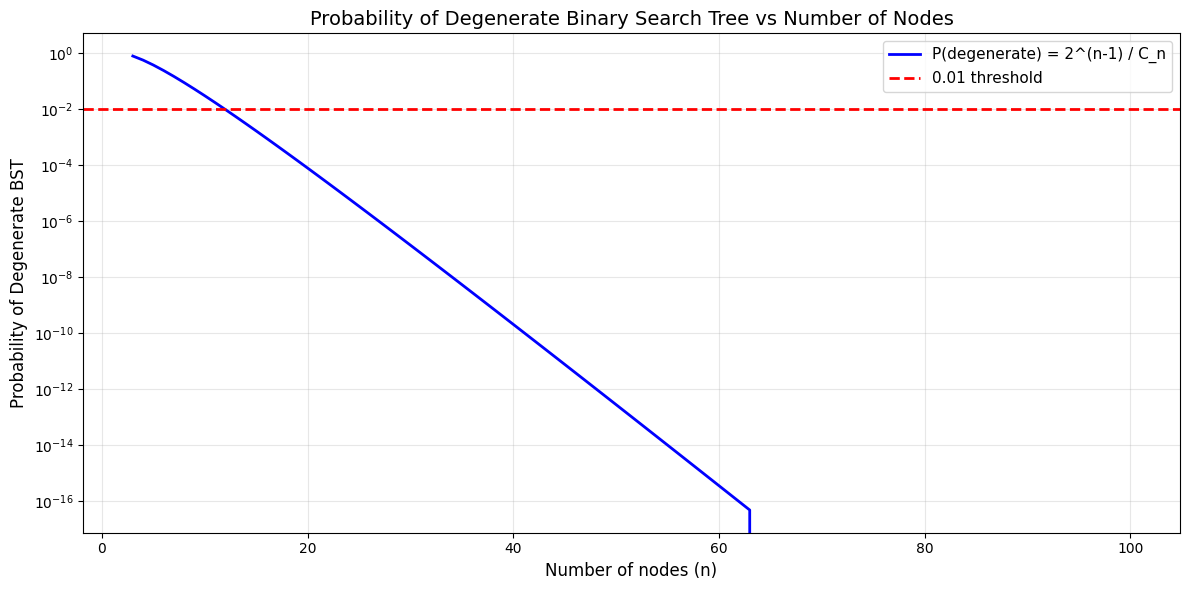

F(6) = 6! = 720
F(4) = 4! = 24
F(3) = 3! = 6
F(8) = 8! = 4.03e+4
F(5) = 5! = 120
F(4) = 4! = 24
F(10) = 10! = 3.63e+6
F(6) = 6! = 720
F(5) = 5! = 120
F(12) = 12! = 4.79e+8
F(7) = 7! = 5,040
F(6) = 6! = 720
F(14) = 14! = 8.72e+10
F(8) = 8! = 4.03e+4
F(7) = 7! = 5,040
F(16) = 16! = 2.09e+13
F(9) = 9! = 3.63e+5
F(8) = 8! = 4.03e+4
F(18) = 18! = 6.40e+15
F(10) = 10! = 3.63e+6
F(9) = 9! = 3.63e+5
F(20) = 20! = 2.43e+18
F(11) = 11! = 3.99e+7
F(10) = 10! = 3.63e+6
F(22) = 22! = 1.12e+21
F(12) = 12! = 4.79e+8
F(11) = 11! = 3.99e+7
F(24) = 24! = 6.20e+23
F(13) = 13! = 6.23e+9
F(12) = 12! = 4.79e+8

Smallest n where P(degenerate) < 0.01: n = 12
F(24) = 24! = 6.20e+23
F(13) = 13! = 6.23e+9
F(12) = 12! = 4.79e+8
P(12) = 0.0098455858


In [73]:
import numpy as np
import matplotlib.pyplot as plt

def catalan(n):
    """
    Calculate the nth Catalan number.
    C_n = (2n)! / ((n+1)! * n!)
    """
    numerator = F(2 * n)
    denominator = F(n + 1) * F(n)
    return numerator // denominator

def degenerate_number(n):
    """
    Calculate the number of degenerate BST structures.
    For n nodes, there are 2^(n-1) degenerate structures.
    """
    return 2 ** (n - 1)

def probability_degenerate(n):
    """
    Calculate probability of degenerate BST.
    P(degenerate) = 2^(n-1) / C_n
    """
    degen = degenerate_number(n)
    cat = catalan(n)
    return degen / cat

# Create array of n values from 3 to 100
n_values = np.arange(3, 101)

# Calculate probabilities for all n values
probabilities = np.array([probability_degenerate(n) for n in n_values])

# Display some sample values
print("Sample values of P(degenerate) for different n:")
print(f"{'n':<5} {'C_n':<12} {'2^(n-1)':<12} {'Probability':<15}")
print("-" * 45)
for n in [3, 5, 10, 15, 20, 50, 100]:
    cat_n = catalan(n)
    degen_n = degenerate_number(n)
    prob = probability_degenerate(n)
    print(f"{n:<5} {cat_n:<12} {degen_n:<12} {prob:.10f}")

# Create plot
plt.figure(figsize=(12, 6))
plt.plot(n_values, probabilities, 'b-', linewidth=2, label='P(degenerate) = 2^(n-1) / C_n')
plt.axhline(y=0.01, color='r', linestyle='--', linewidth=2, label='0.01 threshold')
plt.xlabel('Number of nodes (n)', fontsize=12)
plt.ylabel('Probability of Degenerate BST', fontsize=12)
plt.title('Probability of Degenerate Binary Search Tree vs Number of Nodes', fontsize=14)
plt.grid(True, alpha=0.3)
plt.legend(fontsize=11)
plt.yscale('log')
plt.tight_layout()
plt.show()

# Find smallest n where P < 0.01
smallest_n = None
for n in n_values:
    if probability_degenerate(n) < 0.01:
        smallest_n = n
        break

if smallest_n:
    print(f"\nSmallest n where P(degenerate) < 0.01: n = {smallest_n}")
    print(f"P({smallest_n}) = {probability_degenerate(smallest_n):.10f}")
else:
    print("\nNo n found in range [3, 100] where P < 0.01")

## Problem 19: Password Hacking Attempts

Say a hacker has a list of n distinct password candidates, only one of which will successfully log her into a secure system.

**A.** If she tries passwords from the list at random, deleting those passwords that do not work, what is the probability that her first successful login will be (exactly) on her k-th try?

**B.** Now say the hacker tries passwords from the list at random, but does not delete previously tried passwords from the list. She stops after her first successful login attempt. What is the probability that her first successful login will be (exactly) on her k-th try?

### Solution Strategy

- The hacker has $n$ passwords, thus the sample space can be considered to be $n$
- One password is correct
- Probability for successful login in first attempt: $P(\text{success}) = \frac{1}{n}$
- Probability of unsuccessful login in first attempt: $P(\text{failure}) = 1 - \frac{1}{n} = \frac{n-1}{n}$
- In case of failure, hacker removes the password, effectively reducing the sample space to $n-1$
- Probability of failure in second attempt becomes: $\frac{n-2}{n-1}$
- Probability of failure in $(k-1)$-th attempt: $P(\text{failure on attempt } k-1) = \frac{n-(k-1)}{n-(k-1)-1} = \frac{n-k+1}{n-k}$
- The hacker succeeds at the k-th attempt, meaning the hacker survived $k-1$ failures

**Deriving the success probability at k-th attempt (Part A - without replacement):**

At the k-th attempt, after $(k-1)$ failures:
- Remaining passwords: $n-k+1$
- Probability of failure at k-th attempt: $P(\text{fail at k}) = \frac{n-k}{n-k+1}$
- Probability of success at k-th attempt: $P(\text{success at k}) = 1 - \frac{n-k}{n-k+1} = \frac{1}{n-k+1}$

The formula becomes:
$$P(\text{success at k}) = \underbrace{\frac{n-1}{n} \times \frac{n-2}{n-1} \times \frac{n-3}{n-2} \times \cdots \times \frac{n-k+1}{n-k}}_{\text{(k-1) failures}} \times \underbrace{\frac{1}{n-k+1}}_{\text{success at k}}$$

This is a telescoping product where consecutive terms cancel:

$$= \frac{\cancel{(n-1)} \times \cancel{(n-2)} \times \cancel{(n-3)} \times \cdots \times \cancel{(n-k+1)} \times 1}{n \times \cancel{(n-1)} \times \cancel{(n-2)} \times \cdots \times \cancel{(n-k)} \times \cancel{(n-k+1)}}$$

$$= \frac{1}{n}$$

**Part B - with replacement:**

Since passwords are not deleted, each attempt has the same probabilities:
- Probability of failure per attempt: $P(\text{fail}) = \frac{n-1}{n}$
- Probability of success per attempt: $P(\text{success}) = 1 - \frac{n-1}{n} = \frac{1}{n}$

For success at exactly the k-th attempt (fail $(k-1)$ times, then succeed):

$$P(\text{success at k}) = \underbrace{\frac{n-1}{n} \times \frac{n-1}{n} \times \cdots \times \frac{n-1}{n}}_{(k-1) \text{ times}} \times \frac{1}{n}$$

$$= \left(\frac{n-1}{n}\right)^{k-1} \times \frac{1}{n}$$

$$= \frac{(n-1)^{k-1}}{n^k}$$

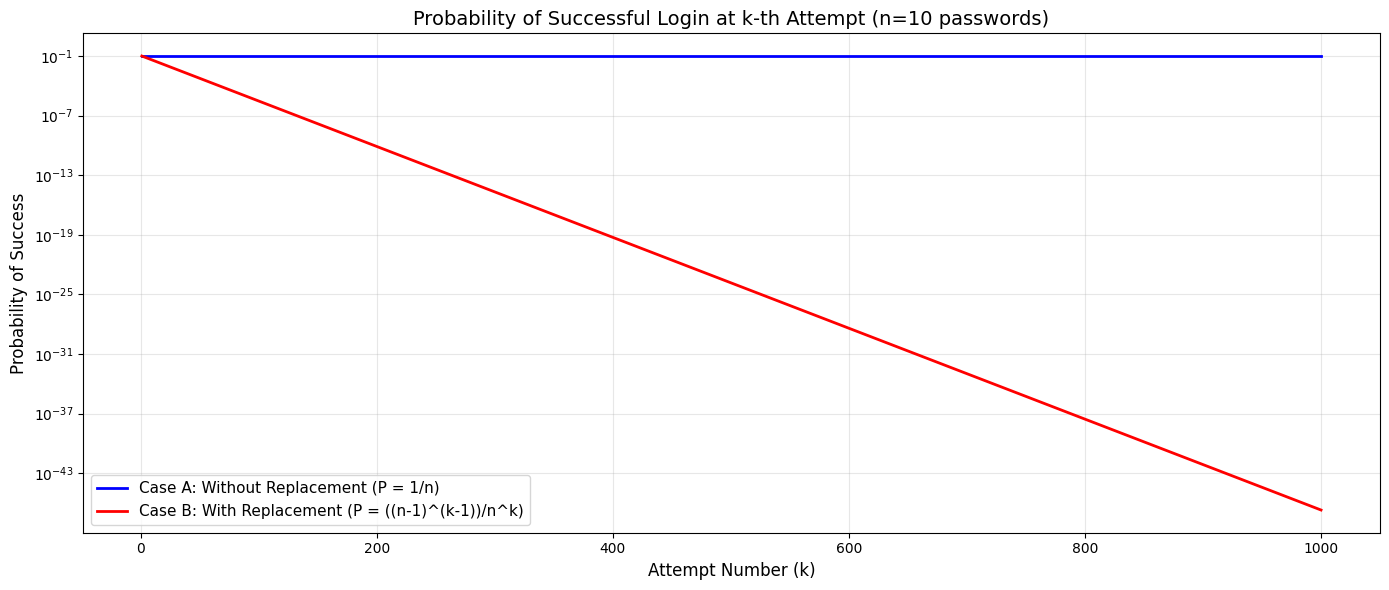

Sample Probabilities (n = 10):
k     Case A (No Replacement)        Case B (With Replacement)     
-----------------------------------------------------------------
1     0.1000000000                   1.000000000000000e-01         
2     0.1000000000                   9.000000000000001e-02         
5     0.1000000000                   6.561000000000000e-02         
10    0.1000000000                   3.874204890000001e-02         
50    0.1000000000                   5.726416897022355e-04         
100   0.1000000000                   2.951266543065283e-06         
500   0.1000000000                   1.468967577200914e-24         
1000  0.1000000000                   1.942079168580772e-47         


In [74]:
def probability_login_success_1(n, k_array):
    """
    Probability of successful login at k-th attempt WITHOUT replacement.
    Result: P = 1/n (constant, independent of k)
    """
    return np.ones_like(k_array, dtype=np.float64) / np.float64(n)

def probability_login_success_2(n, k_array):
    """
    Probability of successful login at k-th attempt WITH replacement.
    Result: P = ((n-1)/n)^(k-1) * (1/n)
    Direct computation using numpy power function.
    Note: For very large k (>100), values underflow to 0, which is correct since P approaches 0.
    """
    n_float = np.float64(n)
    k_float = np.asarray(k_array, dtype=np.float64)
    
    # Direct computation: ((n-1)/n)^(k-1) * (1/n)
    return np.power(np.float64(n - 1) / n_float, k_float - 1.0) * (1.0 / n_float)

# Set number of passwords
n = 10

# Create array of attempts from 1 to 1000
k_values = np.arange(1, 1001, dtype=np.float64)

# Calculate probabilities for both cases using vectorized operations
prob_case_1 = probability_login_success_1(n, k_values)
prob_case_2 = probability_login_success_2(n, k_values)

# Create plot
plt.figure(figsize=(14, 6))

# Plot both cases
plt.plot(k_values, prob_case_1, 'b-', linewidth=2, label='Case A: Without Replacement (P = 1/n)')
plt.plot(k_values, prob_case_2, 'r-', linewidth=2, label='Case B: With Replacement (P = ((n-1)^(k-1))/n^k)')

plt.xlabel('Attempt Number (k)', fontsize=12)
plt.ylabel('Probability of Success', fontsize=12)
plt.title('Probability of Successful Login at k-th Attempt (n=10 passwords)', fontsize=14)
plt.grid(True, alpha=0.3)
plt.legend(fontsize=11)
plt.yscale('log')
plt.tight_layout()
plt.show()

# Display some sample values
print(f"Sample Probabilities (n = {n}):")
print(f"{'k':<5} {'Case A (No Replacement)':<30} {'Case B (With Replacement)':<30}")
print("-" * 65)
for k in [1, 2, 5, 10, 50, 100, 500, 1000]:
    k_array = np.array([k], dtype=np.float64)
    p1 = probability_login_success_1(n, k_array)[0]
    p2 = probability_login_success_2(n, k_array)[0]
    print(f"{k:<5} {p1:<30.10f} {p2:<30.15e}")

## Problem 20: Programming Class Enrollment (Inclusion-Exclusion Principle)

Say a university is offering 3 programming classes: one in Java, one in C++, and one in Python. The classes are open to any of the 100 students at the university. There are:
- a total of 27 students in the Java class
- a total of 26 students in the C++ class
- a total of 18 students in the Python class
- 12 students in both the Java and C++ classes
- 5 students in both the Java and Python classes
- 7 students in both the C++ and Python classes
- 3 students in all three classes (note: these students are also counted as being in each pair of classes in the numbers above)

**A.** If a student is chosen randomly at the university, what is the probability that he or she is not in any of the 3 programming classes?

**B.** If a student is chosen randomly at the university, what is the probability that he or she is taking exactly one of the three programming classes?

**C.** If two students are chosen randomly at the university, what is the probability that at least one of the chosen students is taking at least one programming class?

In [75]:
# Problem 20: Programming Class Enrollment - Constants

# Total students at the university
total_students = 100

# Individual class enrollments
java_students = 27
cpp_students = 26
python_students = 18

# Pairwise intersections
java_cpp_students = 12  # Students in both Java and C++
java_python_students = 5  # Students in both Java and Python
cpp_python_students = 7  # Students in both C++ and Python

# Triple intersection
all_three_students = 3  # Students in all three classes

# Calculate students in only one class (using inclusion-exclusion principle)
java_only_students = java_students - java_cpp_students - java_python_students + all_three_students
cpp_only_students = cpp_students - java_cpp_students - cpp_python_students + all_three_students
python_only_students = python_students - java_python_students - cpp_python_students + all_three_students

# Calculate total students in at least one programming class (inclusion-exclusion principle)
programming_students = (java_students + cpp_students + python_students - 
                        java_cpp_students - java_python_students - cpp_python_students + 
                        all_three_students)
students_not_in_any_class = total_students - programming_students

print("Problem 20: Programming Class Enrollment")
print("=" * 50)
print(f"Total students: {total_students}")
print(f"\nIndividual class enrollments:")
print(f"  Java:   {java_students}")
print(f"  C++:    {cpp_students}")
print(f"  Python: {python_students}")
print(f"\nPairwise intersections:")
print(f"  Java ∩ C++:    {java_cpp_students}")
print(f"  Java ∩ Python: {java_python_students}")
print(f"  C++ ∩ Python:  {cpp_python_students}")
print(f"\nTriple intersection:")
print(f"  Java ∩ C++ ∩ Python: {all_three_students}")
print(f"\nStudents in exactly one class:")
print(f"  Java only:   {java_only_students}")
print(f"  C++ only:    {cpp_only_students}")
print(f"  Python only: {python_only_students}")
print(f"\nTotal students in at least one class: {programming_students}")
print(f"Total students not in any class: {students_not_in_any_class}")

Problem 20: Programming Class Enrollment
Total students: 100

Individual class enrollments:
  Java:   27
  C++:    26
  Python: 18

Pairwise intersections:
  Java ∩ C++:    12
  Java ∩ Python: 5
  C++ ∩ Python:  7

Triple intersection:
  Java ∩ C++ ∩ Python: 3

Students in exactly one class:
  Java only:   13
  C++ only:    10
  Python only: 9

Total students in at least one class: 50
Total students not in any class: 50


In [76]:
# Part A: Probability that a randomly chosen student is not in any class
prob_20_part_a = students_not_in_any_class / total_students

# Part B: Probability that a randomly chosen student is in exactly one class
exactly_one_class_students = java_only_students + cpp_only_students + python_only_students
prob_20_part_b = exactly_one_class_students / total_students

# Part C: Probability that at least one of two randomly chosen students is in at least one class
# P(at least one) = 1 - P(both not in any class)
ways_both_not_in_any = C(students_not_in_any_class, 2)
ways_choose_two_students = C(total_students, 2)
prob_both_not_in_any_class = ways_both_not_in_any / ways_choose_two_students
prob_20_part_c = 1 - prob_both_not_in_any_class

print("\nProblem 20: Solutions")
print("=" * 50)
print(f"Part A: P(not in any class) = {prob_20_part_a:.4f} ({prob_20_part_a*100:.2f}%)")
print(f"Part B: P(exactly one class) = {prob_20_part_b:.4f} ({prob_20_part_b*100:.2f}%)")
print(f"Part C: P(at least one of two in any class) = {prob_20_part_c:.4f} ({prob_20_part_c*100:.2f}%)")
print("\nDetailed breakdown:")
print(f"  Students in exactly one class: {exactly_one_class_students}")
print(f"  Ways to choose 2 from {students_not_in_any_class} not in any class: {ways_both_not_in_any}")
print(f"  Total ways to choose 2 from {total_students}: {ways_choose_two_students}")
print(f"  P(both not in any class) = {prob_both_not_in_any_class:.4f}")

C(50, 2) = 50! / (2! × (50-2)!) = 1,225
C(100, 2) = 100! / (2! × (100-2)!) = 4,950

Problem 20: Solutions
Part A: P(not in any class) = 0.5000 (50.00%)
Part B: P(exactly one class) = 0.3200 (32.00%)
Part C: P(at least one of two in any class) = 0.7525 (75.25%)

Detailed breakdown:
  Students in exactly one class: 32
  Ways to choose 2 from 50 not in any class: 1225
  Total ways to choose 2 from 100: 4950
  P(both not in any class) = 0.2475


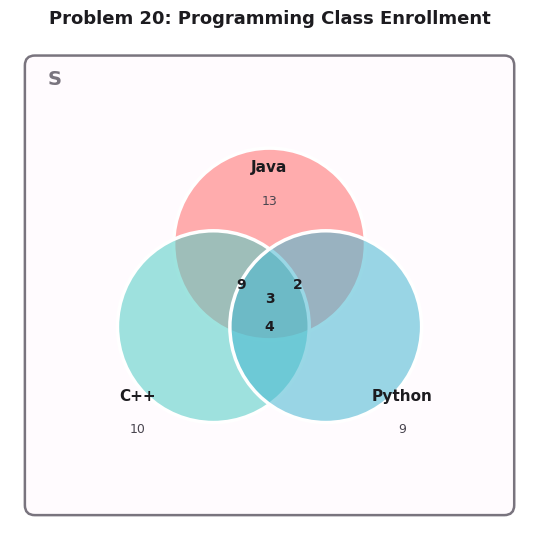


Venn Diagram Regions:
Java only:                        13
C++ only:                         10
Python only:                      9
Java ∩ C++ (not Python):          9
Java ∩ Python (not C++):          2
C++ ∩ Python (not Java):          4
Java ∩ C++ ∩ Python:              3
Students in at least one class:   50
Students in no classes:           50


In [77]:
java_cpp_only = java_cpp_students - all_three_students  # 9
java_python_only = java_python_students - all_three_students  # 2
cpp_python_only = cpp_python_students - all_three_students  # 4

venn(f'''
venn-beta
  title "Problem 20: Programming Class Enrollment"
  set J["Java"]
    text j1["{java_only_students}"]
  set C["C++"]
    text c1["{cpp_only_students}"]
  set P["Python"]
    text p1["{python_only_students}"]
  union J,C["{java_cpp_only}"]
  union J,P["{java_python_only}"]
  union C,P["{cpp_python_only}"]
  union J,C,P["{all_three_students}"]
  style J fill:#FF6B6B
  style C fill:#4ECDC4
  style P fill:#45B7D1
''')

# Print the breakdown of all regions
print("\nVenn Diagram Regions:")
print("=" * 50)
print(f"Java only:                        {java_only_students}")
print(f"C++ only:                         {cpp_only_students}")
print(f"Python only:                      {python_only_students}")
print(f"Java ∩ C++ (not Python):          {java_cpp_only}")
print(f"Java ∩ Python (not C++):          {java_python_only}")
print(f"C++ ∩ Python (not Java):          {cpp_python_only}")
print(f"Java ∩ C++ ∩ Python:              {all_three_students}")
print(f"Students in at least one class:   {programming_students}")
print(f"Students in no classes:           {students_not_in_any_class}")

## Problem 21: Binary String Transmission (Hypergeometric Distribution)

A binary string containing M 0's and N 1's (in arbitrary order, where all orderings are equally likely) is sent over a network.

**Question:** What is the probability that the first r bits of the received message contain exactly k 1's?

**Mathematical Context:**
This is a classic application of the **hypergeometric distribution**. We have a finite population (M + N total bits) with a specific number of success states (N ones), and we're drawing without replacement (sampling the first r bits). We want to find the probability of observing exactly k successes (ones) in our sample.

**Key Insight:**
Since all orderings of the binary string are equally likely, any arrangement of bits is equally probable. This means we can model this as a sampling problem without replacement from a finite population.

**Example:**
- Total bits: M = 8 zeros, N = 5 ones (total = 13 bits)
- First r = 7 bits
- Find P(exactly k = 3 ones in first 7 bits)

## Problem 22: String Hashing into Buckets (Binomial Distribution)

Suppose that m strings are hashed (randomly) into N buckets, assuming that all $N^m$ arrangements are equally likely.

**Question:** Find the probability that exactly k strings are hashed to the first bucket.

**Mathematical Context:**
This is a classic **binomial distribution** problem. Each of the m strings independently has a probability of $\frac{1}{N}$ of being hashed to the first bucket. We want to find the probability that exactly k out of m strings end up in the first bucket.

**Key Insight:**
Since all $N^m$ possible arrangements are equally likely, each string has an equal and independent probability of $\frac{1}{N}$ of landing in any particular bucket (including the first one). The number of strings in the first bucket follows a binomial distribution.

**Formula Derivation:**
- Total possible arrangements: $N^m$
- Arrangements with exactly k strings in first bucket:
  - Choose which k strings go to first bucket: $C(m, k)$
  - Those k strings must go to first bucket: 1 way
  - Remaining (m - k) strings go to any of the other (N - 1) buckets: $(N-1)^{m-k}$ ways
  - Total favorable outcomes: $C(m, k) \cdot (N-1)^{m-k}$

**Probability:**
$$P(\text{exactly k in first bucket}) = \frac{C(m, k) \cdot (N-1)^{m-k}}{N^m} = C(m, k) \cdot \left(\frac{1}{N}\right)^k \cdot \left(\frac{N-1}{N}\right)^{m-k}$$

**Example:**
- m = 10 strings
- N = 3 buckets
- Find P(exactly k = 2 strings in first bucket)

## Problem 23: Comparing Two Random Integers (Order Statistics)

A computer generates two random integers in the range 1 to 12, inclusive, where each value in the range 1 to 12 is equally likely to be generated.

**Question:** What is the probability that the second randomly generated integer has a value that is greater than the first?

**Mathematical Context:**
This problem involves comparing two independent draws from a uniform distribution. We need to find the probability that the second value strictly exceeds the first value.

**Key Insight:**
There are three mutually exclusive outcomes when comparing two values:
1. Second > First  (favorable outcome)
2. Second = First  (tie)
3. Second < First  (unfavorable)

By symmetry, P(Second > First) = P(Second < First), so we can use this symmetry to solve the problem.

**Solution Approach:**

Method 1: Direct Counting
- Total possible outcomes: $12 \times 12 = 144$ (ordered pairs)
- Favorable outcomes (second > first): Count pairs where $(i, j)$ with $i < j$
  - For first = 1: second can be 2, 3, ..., 12 → 11 choices
  - For first = 2: second can be 3, 4, ..., 12 → 10 choices
  - ...
  - For first = 11: second can be 12 → 1 choice
  - For first = 12: second cannot be > 12 → 0 choices
  - Total: $11 + 10 + 9 + ... + 1 + 0 = 66$

Method 2: Using Symmetry
- Total outcomes = 144
- Outcomes where second = first = 12
- By symmetry: P(second > first) = P(second < first)
- Therefore: $2 \cdot P(\text{second} > \text{first}) + P(\text{second} = \text{first}) = 1$
- $P(\text{second} = \text{first}) = \frac{12}{144} = \frac{1}{12}$
- $P(\text{second} > \text{first}) = \frac{1 - \frac{1}{12}}{2} = \frac{11}{24}$

**Example:**
- First integer: 5
- Second integer should be > 5, so {6, 7, 8, 9, 10, 11, 12}
- Number of favorable outcomes: 7

## Problem 24: Fair Game Simulation (Monte Carlo Simulation & Exact Probability)

**[Coding Problem - Monte Carlo Simulation]**

Consider a game that uses a generator which produces independent random integers between 1 and 100 inclusive. 

**Game Rules:**
- **Player 1:** Start with S = 0. Add random numbers until S > 100. Record the last number added as 'x'.
- **Player 2:** Continue adding random numbers to S until S > 200. Record the last number added as 'y'.
- **Winner:** The player with the highest number wins (if y > x, Player 2 wins).

**Questions:**
1. **Is this game fair?** (Equal probability for each player to win?)
2. **What is the probability that Player 2 wins?** (Estimate using 100,000 simulations)
3. **Extra Credit:** Calculate the exact probability analytically.

**Key Observations:**
- Player 1 generates numbers until sum exceeds 100, getting a last number x
- Player 2 starts from the current sum (which is >100) and generates until sum exceeds 200, getting a last number y
- The question is whether y > x with probability > 0.5 (advantage to Player 2), < 0.5 (advantage to Player 1), or = 0.5 (fair)

**Mathematical Context:**
This problem combines:
- **Simulation techniques** - Monte Carlo method to estimate probabilities
- **Random walk theory** - Cumulative sums of random variables
- **Probability theory** - Computing exact probabilities for complex scenarios

**Example Scenario:**
- Player 1 rolls: 25, 40, 50 → S = 115 > 100, x = 50
- Player 2 rolls: 35, 80 → S = 230 > 200, y = 80
- Player 2 wins! (80 > 50)

In [78]:
def random_1_100():
    """
    Returns a random integer between 1 and 100 (inclusive) using numpy.
    
    Returns:
        int: A random integer in range [1, 100]
    """
    return np.random.randint(1, 101)

def play_game():
    """
    Simulates a game where two players get random values.
    
    Returns:
        tuple: (player1, player2) where each is a random value between 1 and 100
    """
    player1 = random_1_100()
    player2 = random_1_100()
    return (player1, player2)

# Simulate the game multiple times
PLAY_GAMES = 100000
player1_wins = 0
player2_wins = 0

for _ in range(PLAY_GAMES):
    p1, p2 = play_game()
    if p2 > p1:
        player2_wins += 1
    else:
        player1_wins += 1

# Calculate probabilities
prob_player1 = player1_wins / PLAY_GAMES
prob_player2 = player2_wins / PLAY_GAMES

print(f"Simulation Results ({fmt(PLAY_GAMES)} games):")
print(f"Player 1 wins: {fmt(player1_wins)}")
print(f"Player 2 wins: {fmt(player2_wins)}")
print(f"\nProbability that Player 1 wins: {fmt(prob_player1)}")
print(f"Probability that Player 2 wins: {fmt(prob_player2)}")

Simulation Results (1.00e+5 games):
Player 1 wins: 5.05e+4
Player 2 wins: 4.95e+4

Probability that Player 1 wins: 0.505480
Probability that Player 2 wins: 0.494520


## Problem 25: Find the Mistake

A web site receives **8 hits** in a particular second. The web site is powered by **5 computers**, each hit can be serviced by any computer.

A student answer uses the divider method:
$$\binom{n+r-1}{r-1} = \binom{11}{4} = 330$$

**Question:** Find the mistake in this student answer.

In [79]:
# Problem 25: Find the Mistake


## Problem 26: DNA-turn

A "DNA-turn" has **11 base pairs**. Each base pair can take on one of four distinct values: {A, T, G, C}.

**Question:** How many distinct DNA-turns are there?

In [80]:
# Problem 26: DNA-turn


## Problem 27: Substitution Cipher

A substitution cipher is derived from orderings of the **26-letter English alphabet** (21 consonants, 5 vowels), each letter appearing exactly once.

How many orderings exist if:
- **(a)** There are no other restrictions?
- **(b)** The letters **Q and U** must be next to each other (in any order)?
- **(c)** All **five vowels** must be next to each other?
- **(d)** **No two vowels** can be next to each other?

In [81]:
# Problem 27: Substitution Cipher


## Problem 28: Card Counting

A card game uses **two standard decks** (104 total cards; 52 cards each with 13 values × 4 suits). Cards are only distinguishable by **suit and value**, not by which deck they came from.

- **(a)** In how many **distinct ways** can the 104 cards be ordered?
- **(b)** You are dealt **two cards**. How many distinct pairs of cards can you be dealt? (Order does not matter.)

In [82]:
# Problem 28: Card Counting


## Problem 29: Investment Strategies

You have **$20 million** to invest among **4 companies**, in integral units of $1 million. Minimum investments are **$1M, $2M, $3M, $4M** for companies 1–4 respectively.

How many investment strategies exist if:
- **(a)** An investment **must** be made in each company?
- **(b)** Investments must be made in **at least 3** of the 4 companies?

In [83]:
# Problem 29: Investment Strategies


## Problem 30: Student Project Groups

**Question:** How many ways can you split a class of **99 students** into **33 project groups of 3 students** each?

Neither the order of the groups nor the order of students within groups matters.

In [84]:
# Problem 30: Student Project Groups


## Problem 31: Bounded Integer Vectors

Determine the number of vectors $(x_1, x_2, \ldots, x_n)$ such that each $x_i$ is a **non-negative integer** and:

$$\sum_{i=1}^{n} x_i \leq k$$

where $k$ is a constant non-negative integer. ($n$ and $k$ may appear in your answer.)

In [85]:
# Problem 31: Bounded Integer Vectors


## Problem 32: Robot on a Grid

A robot $\Theta$ lives on an $n \times m$ grid, starting at cell $(1,1)$, and can only step **right** or **down**. The destination is cell $(n,m)$.

- **(a)** How many distinct paths are there with **no additional constraints**?
- **(b)** How many paths if the robot **must start by moving right**?
- **(c)** How many paths if the robot **changes direction exactly 3 times**?
  - e.g., [down, right, right, down] = 2 direction changes.

In [86]:
# Problem 32: Robot on a Grid


## Problem 33: Web Site Hits

A web site receives **8 hits**. It is powered by **5 computers**, each capable of handling any number of requests.

- **(a)** How many distinct ways can the 8 hits be distributed if all hits are **identical**?
- **(b)** How many distinct ways if the hits consist of **5 identical requests for page A** and **3 identical requests for page B** (A and B are distinguishable)?

In [87]:
# Problem 33: Web Site Hits


## Problem 34: Hacker Passwords

A hacker has a list of $n$ **distinct password candidates**; only one works.

- **(a)** She tries at random, **deleting** failed passwords. What is the probability her first successful login is **exactly** on her **5th** try?
- **(b)** She tries at random but does **not delete** failed passwords (may repeat). What is the probability her first successful login is **exactly** on her **5th** try?

In [88]:
# Problem 34: Hacker Passwords


## Problem 35: Poker Hands

Assuming all **5-card poker hands** from a standard **52-card deck** are equally likely, what is the probability of being dealt:

- **(a)** A **flush**? (All 5 cards of the same suit, including straight flushes.)
- **(b)** **Two pairs**? (Card values $a, a, b, b, c$ where $a, b, c$ are all distinct.)
- **(c)** **Three of a kind**? (Card values $a, a, a, b, c$ where $a, b, c$ are all distinct.)

In [89]:
# Problem 35: Poker Hands


## Problem 36: Email Distribution

**20 distinguishable emails** are sent to **12 distinct users**; each email is equally likely to go to any user.

**Question:** What is the probability that **exactly 4 users receive exactly 2 emails each** and **exactly 3 users receive exactly 4 emails each**?

In [90]:
# Problem 36: Email Distribution


## Problem 37: Seating in a Row

How many ways can **16 people** be seated in a row if:
- **(a)** There are **no restrictions**?
- **(b)** Two specific people **A and B cannot sit immediately next to each other**?
- **(c)** There are **8 adults and 8 children**, and **no two adults** nor **two children** can sit next to each other?
- **(d)** There are **8 married couples** and **each couple must sit together**?

In [91]:
# Problem 37: Seating in a Row


## Problem 38: Zoo Exhibit

A zoo exhibit uses **5 of 10 bird species** and **5 of 9 reptile species**.

How many exhibits are possible if:
- **(a)** There are **no additional restrictions**?
- **(b)** **2 particular bird species** cannot both be in the exhibit?
- **(c)** Any bird species can be selected, but **1 particular bird species cannot be placed with 1 particular reptile species**?

In [92]:
# Problem 38: Zoo Exhibit


## Problem 39: Piano Melodies

A piano octave has **12 notes**: 5 black-key notes and 7 white-key notes. A melody is a sequence of **6 notes (2 black, 4 white)**; notes need not be distinct.

How many melodies are there if:
- **(a)** No further restrictions?
- **(b)** The **4 white notes cannot all be adjacent** in the melody (e.g., $[WWWWBB]$ is forbidden but $[WWWBWB]$ is fine)?
- **(c)** **No note is repeated**?
- **(d)** **No note is repeated** and the white notes must be in **ascending order** in the melody?

In [93]:
# Problem 39: Piano Melodies


## Problem 40: Hacker Passwords (General)

A hacker has a list of $n$ **distinct password candidates**; only one works.

- **(a)** She **deletes** failed passwords. What is the probability her first successful login is exactly on her **$k$-th try**? (Assume $k \leq n$.)
- **(b)** She does **not delete** failed passwords (may repeat). What is the probability her first successful login is exactly on her **$k$-th try**?

In [94]:
# Problem 40: Hacker Passwords (General)


## Problem 41: Sleepwalking Students (Pigeonhole Principle)

Each square of a **9×9 checkerboard** is initially occupied by one of **81 students**. At noon, each student wakes and randomly **sleepwalks to a valid adjacent square** (horizontally or vertically, not diagonally).

**Question:** Argue that the probability that **two or more students end up on the same square is 1**.

In [95]:
# Problem 41: Sleepwalking Students


## Problem 42: Spot the Error

For each scenario, determine if the proposed answer is **correct**, **undercounted**, or **overcounted** — and explain:

- **(a)** The number of ways to arrange **8 people around a circular table** (no equivalent rotations) is: $8!$
- **(b)** **9 different pizza toppings** (each either on or not). Number of ways to choose 3 different pizzas for 3 children:
$$\frac{(2^9)(2^9-1)(2^9-2)}{3!}$$
- **(c)** Distribute **10 indistinguishable pizzas** to 3 siblings and **5 indistinguishable burgers** to 4 grandparents:
$$\binom{13}{3} \cdot \binom{9}{4}$$
- **(d)** 3 email servers (initially empty), $10^9$ unique emails routed randomly. Number of distributions where **no server is empty**:
$$3^{10^9} - \binom{3}{1}2^{10^9}$$

In [96]:
# Problem 42: Spot the Error


## Problem 43: Combinatorial Proofs

Give **combinatorial proofs** of:

- **(a)** $\displaystyle\binom{n}{2} = \sum_{k=1}^{n-1} k$

- **(b)** $\displaystyle 2^n - 1 = \sum_{i=0}^{n-1} 2^i$
  *(Hint: Imagine a tournament bracket.)*

In [97]:
# Problem 43: Combinatorial Proofs


## Problem 44: Candy Distributions

You collected **$N$ total candies**, $K$ of which are **Kit-Kats**.

- **(a)** Your parent lets you eat **$n$ of them tonight**; you grab $n$ randomly. Let $X$ = number of Kit-Kats grabbed. What is $P(X = k)$ for valid values of $k$?

- **(b)** You eat one at a time (randomly) and **stop when you've eaten $k$ Kit-Kats**. Let $Y$ = total candies eaten (including the $k$-th Kit-Kat). What is $P(Y = n)$ for valid $n$?

In [98]:
# Problem 44: Candy Distributions


## Problem 45: Class Registration

**100 students** each take exactly 1 CS class. Probabilities (independently):
- Discrete Math: 0.3
- Intro Programming: 0.4
- Data Structures: 0.1
- Computer Architecture: 0.2

**Question:** What is the probability that **simultaneously**:
- 31 sign up for discrete-math
- 39 sign up for intro-programming
- 7 sign up for data-structures
- 23 sign up for computer-architecture?

In [99]:
# Problem 45: Class Registration


## Problem 46: CAPTCHA Robot Detection

A website gives **7 independent CAPTCHA tests**. 
- A **human** succeeds each test with probability **0.95**
- A **robot** succeeds each test with probability **0.3**
- **10%** of visitors are robots

A visitor is **flagged** if they fail at least one test.

- **(a)** If a visitor is a **robot**, what is the probability they get **flagged**?
- **(b)** If a visitor is **human**, what is the probability they get **flagged**?
- **(c)** Given a visitor **gets flagged**, what is the probability they are a **robot**?

In [100]:
# Problem 46: CAPTCHA Robot Detection


## Problem 47: Decks of Cards

Four decks: **red** (52 cards), **green** (104), **blue** (156), **yellow** (208). A standard 52-card deck has 13 ranks × 4 suits.

- **(a)** We draw from a deck with probability **proportional to its size**. Give the probability of drawing from each deck (4 values summing to 1).
- **(b)** Drawing **3 cards from the blue deck without replacement**: what is the probability of observing the sequence **(King of Hearts, Ace of Spades, King of Hearts)** in order?
- **(c)** Given we observed **(King of Hearts, Ace of Spades, King of Hearts)** in order from a **randomly chosen deck** (without replacement), what is the probability it was the **blue deck**?

In [101]:
# Problem 47: Decks of Cards


## Problem 48: Home Security System

A security system alerts police if sensor **V** (video) or sensor **L** (laser) detects motion.

Given motion outside: $P(V \text{ detects}) = 0.95$, $P(L \text{ detects}) = 0.8$  
Given no motion: $P(L \text{ false positive}) = 0.05$, $P(V \text{ false positive}) = 0.1$  
$P(\text{motion outside}) = 0.7$  
Sensors are **conditionally independent** given motion/no-motion.

- **(a)** Given **motion outside** and **V does not detect it**, what is the probability **L detects motion**?
- **(b)** Given **motion outside**, what is the probability the **system alerts police**?
- **(c)** What is the probability of a **false alarm** (no motion but police alerted)?
- **(d)** Given **both sensors detect motion**, what is the probability there is actually a **moving object**?

In [102]:
# Problem 48: Home Security System


## Problem 49: Ping Pong (Coding + Written)

What is the probability of **winning a ping-pong game** to $n$ points with probability $p$ of winning each point, needing to **win by at least 2**? (Scores can go beyond $n$, e.g. 26:24.)

- **(a)** Implement `part_a(n, p)` — returns the probability of winning the game.
- **(b)** Implement `part_b`:
  - **(i)** Generate a plot of win probability vs. $p$ for several values of $n$.
  - **(ii)** In ≤ 2–3 sentences, describe the interesting pattern as $n$ gets larger (steepness of the curve) and explain why.
  - **(iii)** Each curve approximately passes through **3 common points**. Give them as $(x_1, y_1), (x_2, y_2), (x_3, y_3)$ and explain mathematically why.

In [103]:
# Problem 49: Ping Pong

def part_a(n, p):
    """
    Returns the probability of winning a ping-pong game to n points,
    with probability p of winning each point, needing to win by at least 2.
    """
    pass  # TODO: implement

def part_b():
    """
    (i)   Generate plot of win probability vs p for several values of n.
    (ii)  Describe the pattern as n gets larger.
    (iii) Identify the 3 common points all curves pass through.
    """
    pass  # TODO: implement


## Problem 50: Pokémon "Catch 'Em All" (Coding)

Using a file `pokemon.txt` with **encounter rates** and **catch rates** for each Pokémon, implement:

- **(a)** `part_a()` — Expected number of encounters to catch one specific Pokémon.
- **(b)** `part_b()` — Expected number of encounters to catch all Pokémon.
- **(c)** `part_c()` — Probability of catching all Pokémon within a given number of encounters.
- **(d)** `part_d()` — Display or summarize results.

In [104]:
# Problem 50: Pokémon "Catch 'Em All"

def part_a():
    pass  # TODO: implement

def part_b():
    pass  # TODO: implement

def part_c():
    pass  # TODO: implement

def part_d():
    pass  # TODO: implement
